# Human Liver Biomarkers — Statistical Analysis

**Dataset**: Human Liver Biomarkers — liver enzymes, proteins, and patient clinical metadata
**Author**: Henri-Philippe Konan

---

## Project overview

This project investigates the relationships between serum biomarkers and liver disease
severity in a cohort of adult patients. The analysis moves from raw data to interpretable
statistical models through three main stages:

1. **Data cleaning** — standardize, validate, and impute missing or invalid values.
2. **Exploratory data analysis (EDA)** — describe distributions and correlations.
3. **Statistical modeling** — OLS regression for ALT and AST, followed by between-group
   comparisons and logistic regression for disease stage prediction.

---

## Research questions

| # | Question |
|---|---|
| 1 | Which serum biomarkers best predict alanine aminotransferase (ALT) activity? |
| 2 | Which serum biomarkers best predict aspartate aminotransferase (AST) activity? |
| 3 | Do ALT and AST differ significantly across liver disease stages? |
| 4 | Does elevated ALT increase the odds of being diagnosed with advanced liver disease? |

---

## Dataset variables

| Variable | Type | Description |
|---|---|---|
| `patient_id` | ID | Unique patient identifier |
| `age` | Continuous | Age in years |
| `sex` | Categorical | Male / Female |
| `bmi` | Continuous | Body Mass Index (kg/m²) |
| `alt` | Continuous | Alanine aminotransferase, U/L |
| `ast` | Continuous | Aspartate aminotransferase, U/L |
| `albumin` | Continuous | Serum albumin, g/dL |
| `bilirubin` | Continuous | Total bilirubin, mg/dL |
| `protein_a–d` | Continuous | Protein expression levels (arbitrary units) |
| `liver_status` | Ordinal | Disease stage: 0=Healthy, 1=Fibrosis, 2=Cirrhosis, 3=Cancer |

## 0. Setup

In [1]:
import sys
sys.path.insert(0, 'src')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import statsmodels.formula.api as smf
import statsmodels.api as sm
from statsmodels.stats.multicomp import pairwise_tukeyhsd

from data_utils import stats_print, impute_from_distribution
from visualization import plot_distributions, plot_regplots, plot_correlation_heatmap
from ols_utils import ols_diagnostics, model_summary_row

%matplotlib inline
sns.set_theme(style="whitegrid", font_scale=1.05)
plt.rcParams["figure.dpi"] = 110

In [2]:
# Update DATA_PATH if the CSV is stored elsewhere.
DATA_PATH = r"C:\Users\henri-philippe.konan\Desktop\Perso\Devenir data scientist\IBM data science professional certificate\Portfolio\Human_Liver_Biomarkers.csv"

dfs = pd.read_csv(DATA_PATH)
print(f"Dataset loaded: {dfs.shape[0]:,} rows × {dfs.shape[1]} columns")
dfs.head()

Dataset loaded: 800 rows × 13 columns


,Patient_ID,Age,Sex,BMI,ALT,AST,Albumin,Bilirubin,Protein_A,Protein_B,Protein_C,Protein_D,Liver_Status
0,HLB0062,75,Female,28.3,29.0,40.7,4.35,0.72,5.88,5.87,7.71,7.49,Healthy
1,HLB0800,28,Female,23.8,22.6,70.8,4.65,1.27,7.91,8.23,6.01,8.56,Fibrosis
2,HLB0748,72,Male,25.7,35.9,15.6,4.30,0.79,7.36,7.01,4.83,4.43,Healthy
3,HLB0669,33,Male,26.0,26.3,35.6,4.44,1.03,7.16,6.75,NaN,7.38,Healthy
4,HLB0727,57,Male,21.9,27.2,14.6,4.60,0.78,5.99,NaN,7.96,4.62,Healthy


---
## 1. Data Cleaning

Raw data commonly contains noise, inconsistent formatting, and missing values.
The steps below follow a deliberate order to avoid propagating errors:

1. **Standardize column names** — lowercase, strip whitespace.
2. **Remove duplicate records** — keep first occurrence per `patient_id`.
3. **Impute missing categorical values** — `sex` via proportional random sampling;
   `liver_status` via mode.
4. **Handle invalid continuous values** — negative ALT/AST are physiologically
   impossible; replace with NaN then impute by random sampling from the observed
   distribution (preserves the right-skewed shape better than mean/median).
5. **Impute remaining continuous variables** — `albumin`, `bilirubin`, `protein_a–d`
   using mean (symmetric) or median (skewed), chosen automatically by `stats_print`.
6. **Drop rows with missing critical columns** — `patient_id`, `age`, `sex`, `bmi`, `alt`.
7. **Encode disease stage as ordinal integer** — Healthy=0, Fibrosis=1, Cirrhosis=2, Cancer=3.

In [3]:
dfs.columns = dfs.columns.str.strip().str.lower()
print("Columns:", dfs.columns.tolist())

Columns: ['patient_id', 'age', 'sex', 'bmi', 'alt', 'ast', 'albumin', 'bilirubin', 'protein_a', 'protein_b', 'protein_c', 'protein_d', 'liver_status']


In [4]:
n_before = len(dfs)
dfs["patient_id"].drop_duplicates(inplace=True, keep="first")
dfs = dfs.dropna(subset=["patient_id"]).reset_index(drop=True)
print(f"Removed {n_before - len(dfs)} duplicate / missing patient_id rows.")
print("\nMissing values per column:")
print(dfs.isnull().sum())

Removed 0 duplicate / missing patient_id rows.

Missing values per column:
patient_id       0
age              0
sex             20
bmi             56
alt             56
ast             65
albumin         68
bilirubin       63
protein_a       60
protein_b       67
protein_c       78
protein_d       72
liver_status     0
dtype: int64


In [5]:
# Proportional random imputation preserves the observed Male/Female ratio.
values_sex  = dfs["sex"].value_counts(normalize=True)
missing_sex = dfs["sex"].isnull()
n_missing   = missing_sex.sum()
print(f"Missing sex values: {n_missing} ({n_missing / len(dfs) * 100:.1f}%)")
print("Observed distribution:", values_sex.to_dict())

np.random.seed(42)
dfs.loc[missing_sex, "sex"] = np.random.choice(
    values_sex.index, size=n_missing, p=values_sex.values
)
print(f"Missing sex after imputation: {dfs['sex'].isnull().sum()}")

Missing sex values: 20 (2.5%)
Observed distribution: {'Female': 0.5064102564102564, 'Male': 0.4935897435897436}
Missing sex after imputation: 0


In [6]:
dfs["bmi"] = dfs["bmi"].fillna(dfs["bmi"].mean())
print(f"Missing BMI after imputation: {dfs['bmi'].isnull().sum()}")

Missing BMI after imputation: 0


In [7]:
# Negative enzyme activity is physiologically impossible → treat as data error.
dfs.loc[dfs["alt"] < 0, "alt"] = np.nan
dfs["alt"] = impute_from_distribution(dfs["alt"], seed=42)
print(f"Missing ALT after imputation: {dfs['alt'].isnull().sum()}")

Missing ALT after imputation: 0


In [8]:
dfs.loc[dfs["ast"] < 0, "ast"] = np.nan
dfs["ast"] = impute_from_distribution(dfs["ast"], seed=42)
print(f"Missing AST after imputation: {dfs['ast'].isnull().sum()}")

Missing AST after imputation: 0


In [9]:
for col in ["albumin", "bilirubin", "protein_a", "protein_b", "protein_c", "protein_d"]:
    dfs[col] = stats_print(col.replace("_", " ").title(), dfs[col])


--- Albumin ---
  mean=4.19  median=4.29  std=0.53  min=1.8  max=5.29
  Symmetry score=0.184 → imputed 68 missing value(s) with mean (4.19)

--- Bilirubin ---
  mean=1.19  median=1.01  std=0.69  min=0.1  max=4.38
  Symmetry score=0.255 → imputed 63 missing value(s) with median (1.01)

--- Protein A ---
  mean=6.74  median=6.69  std=1.05  min=2.97  max=9.57
  Symmetry score=0.045 → imputed 60 missing value(s) with mean (6.74)

--- Protein B ---
  mean=6.72  median=6.7  std=1.0  min=3.5  max=9.8
  Symmetry score=0.015 → imputed 67 missing value(s) with mean (6.72)

--- Protein C ---
  mean=6.27  median=6.25  std=1.03  min=3.28  max=10.33
  Symmetry score=0.016 → imputed 78 missing value(s) with mean (6.27)

--- Protein D ---
  mean=6.79  median=6.71  std=1.06  min=3.44  max=10.05
  Symmetry score=0.074 → imputed 72 missing value(s) with mean (6.79)


In [10]:
dfs["liver_status"] = dfs["liver_status"].fillna(dfs["liver_status"].mode()[0])
dfs["liver_status"] = dfs["liver_status"].replace(
    {"Healthy": 0, "Fibrosis": 1, "Cirrhosis": 2, "Cancer": 3}
)
print("Liver status distribution (ordinal):")
print(dfs["liver_status"].value_counts().sort_index())

Liver status distribution (ordinal):
liver_status
0    405
1    193
2    127
3     75
Name: count, dtype: int64


C:\Users\henri-philippe.konan\AppData\Local\Temp\ipykernel_11544\4191858615.py:2: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  dfs["liver_status"] = dfs["liver_status"].replace(


In [11]:
critical = ["patient_id", "age", "sex", "bmi", "alt"]
dfs = dfs.dropna(subset=critical).reset_index(drop=True)
print(f"Final dataset: {dfs.shape[0]:,} rows × {dfs.shape[1]} columns")
print("\nFinal missing-values check:")
print(dfs.isnull().sum())

Final dataset: 800 rows × 13 columns

Final missing-values check:
patient_id      0
age             0
sex             0
bmi             0
alt             0
ast             0
albumin         0
bilirubin       0
protein_a       0
protein_b       0
protein_c       0
protein_d       0
liver_status    0
dtype: int64


---
## 2. Exploratory Data Analysis

- **Univariate**: distributions of all biomarkers, stratified by sex.
- **Bivariate**: pairwise regression plots, barplots by disease stage.
- **Multivariate**: Pearson correlation matrix, pairplot, group-level means.

In [12]:
BIOMARKERS   = ["alt", "ast", "albumin", "bilirubin",
                "protein_a", "protein_b", "protein_c", "protein_d"]
STAGE_LABELS = {0: "Healthy", 1: "Fibrosis", 2: "Cirrhosis", 3: "Cancer"}

dfs[BIOMARKERS + ["age", "bmi"]].describe().T.round(2)

,count,mean,std,min,25%,50%,75%,max
alt,800.0,49.88,41.33,0.70,23.30,34.70,63.00,242.60
ast,800.0,44.97,36.83,1.10,20.88,30.85,55.02,201.40
albumin,800.0,4.19,0.51,1.80,3.96,4.24,4.53,5.29
bilirubin,800.0,1.17,0.66,0.10,0.73,1.01,1.44,4.38
protein_a,800.0,6.74,1.01,2.97,6.09,6.74,7.38,9.57
protein_b,800.0,6.72,0.96,3.50,6.14,6.72,7.32,9.80
protein_c,800.0,6.27,0.98,3.28,5.68,6.27,6.86,10.33
protein_d,800.0,6.79,1.01,3.44,6.17,6.79,7.41,10.05
age,800.0,51.73,14.93,18.00,42.00,52.00,61.00,90.00
bmi,800.0,26.08,3.88,16.00,23.78,26.08,28.50,37.40


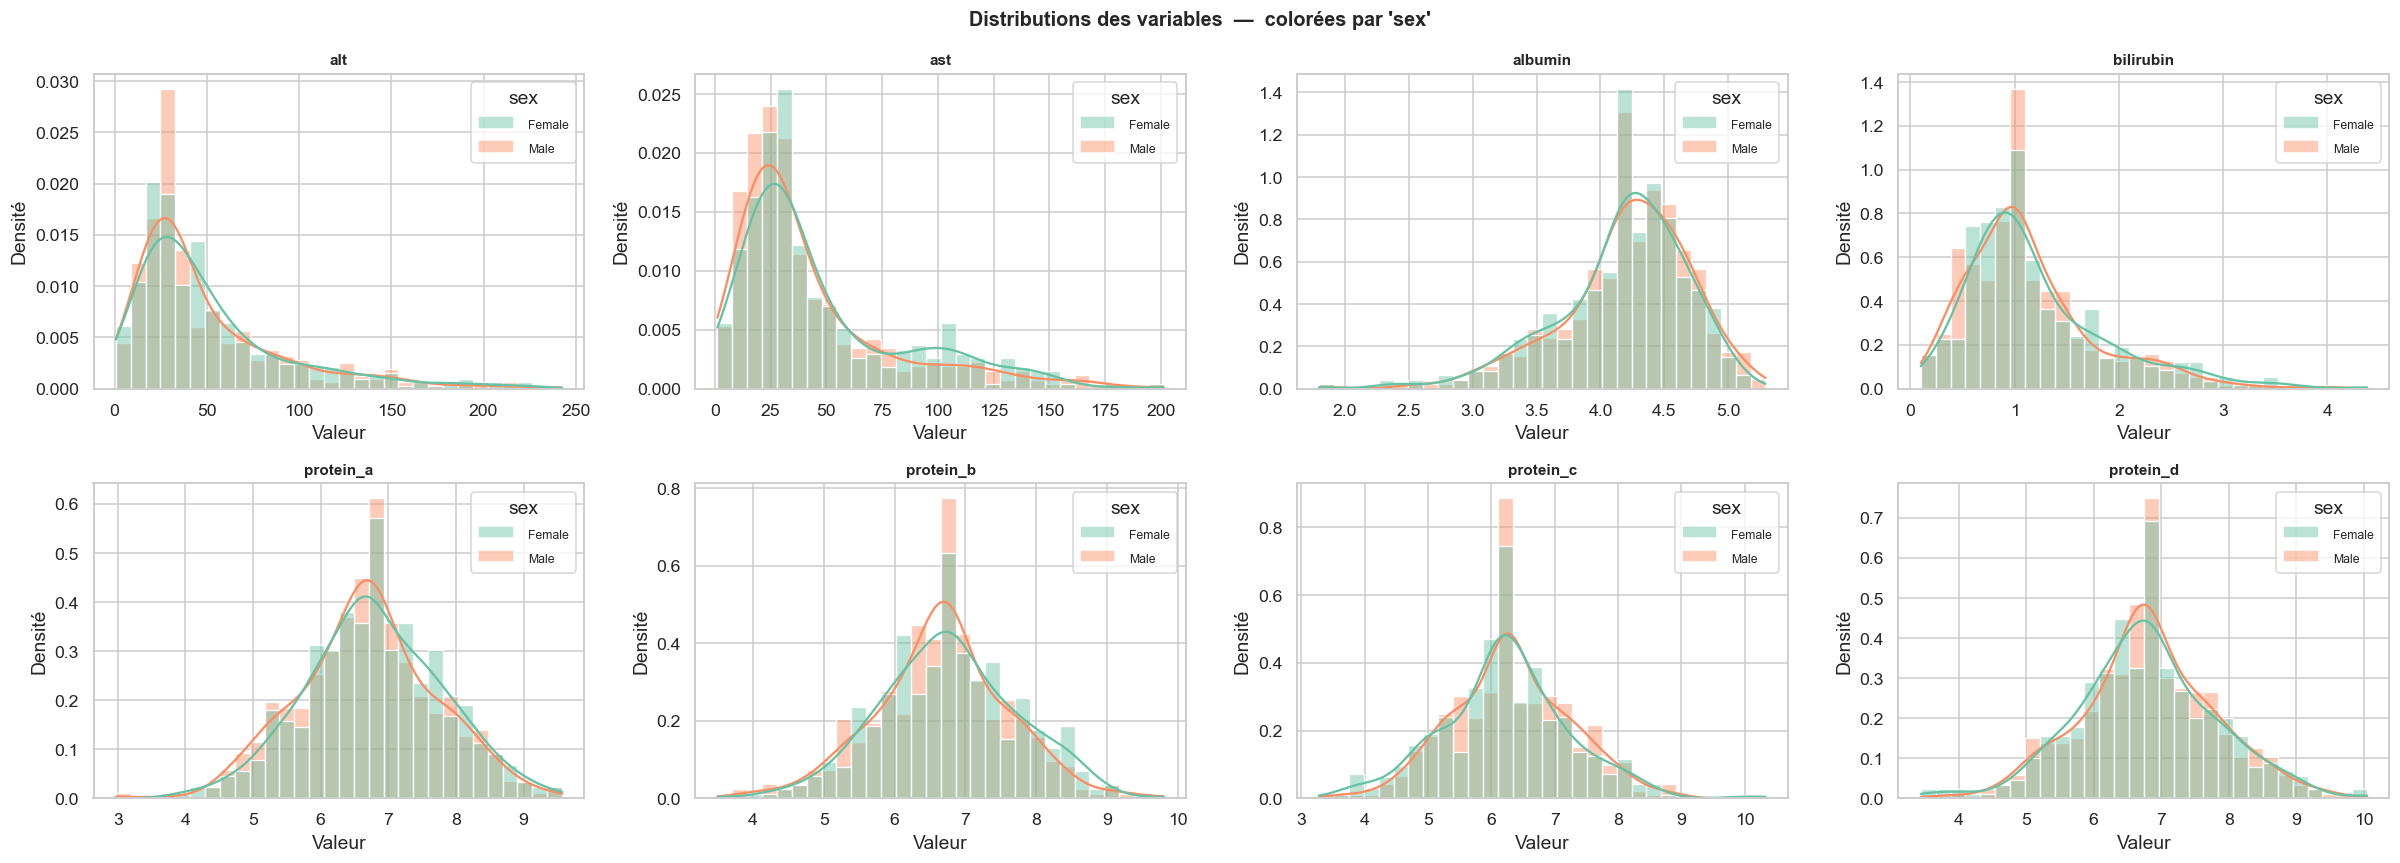

In [13]:
plot_distributions(dfs, BIOMARKERS, group_col="sex", ncols=4)

C:\Users\henri-philippe.konan\AppData\Local\Temp\ipykernel_11544\936530166.py:8: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[i].set_xticklabels(
C:\Users\henri-philippe.konan\AppData\Local\Temp\ipykernel_11544\936530166.py:8: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[i].set_xticklabels(
C:\Users\henri-philippe.konan\AppData\Local\Temp\ipykernel_11544\936530166.py:8: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[i].set_xticklabels(
C:\Users\henri-philippe.konan\AppData\Local\Temp\ipykernel_11544\936530166.py:8: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[i].set_xticklabels(
C:\Users\henri-philippe.konan\AppData\Local\Temp\ipykern

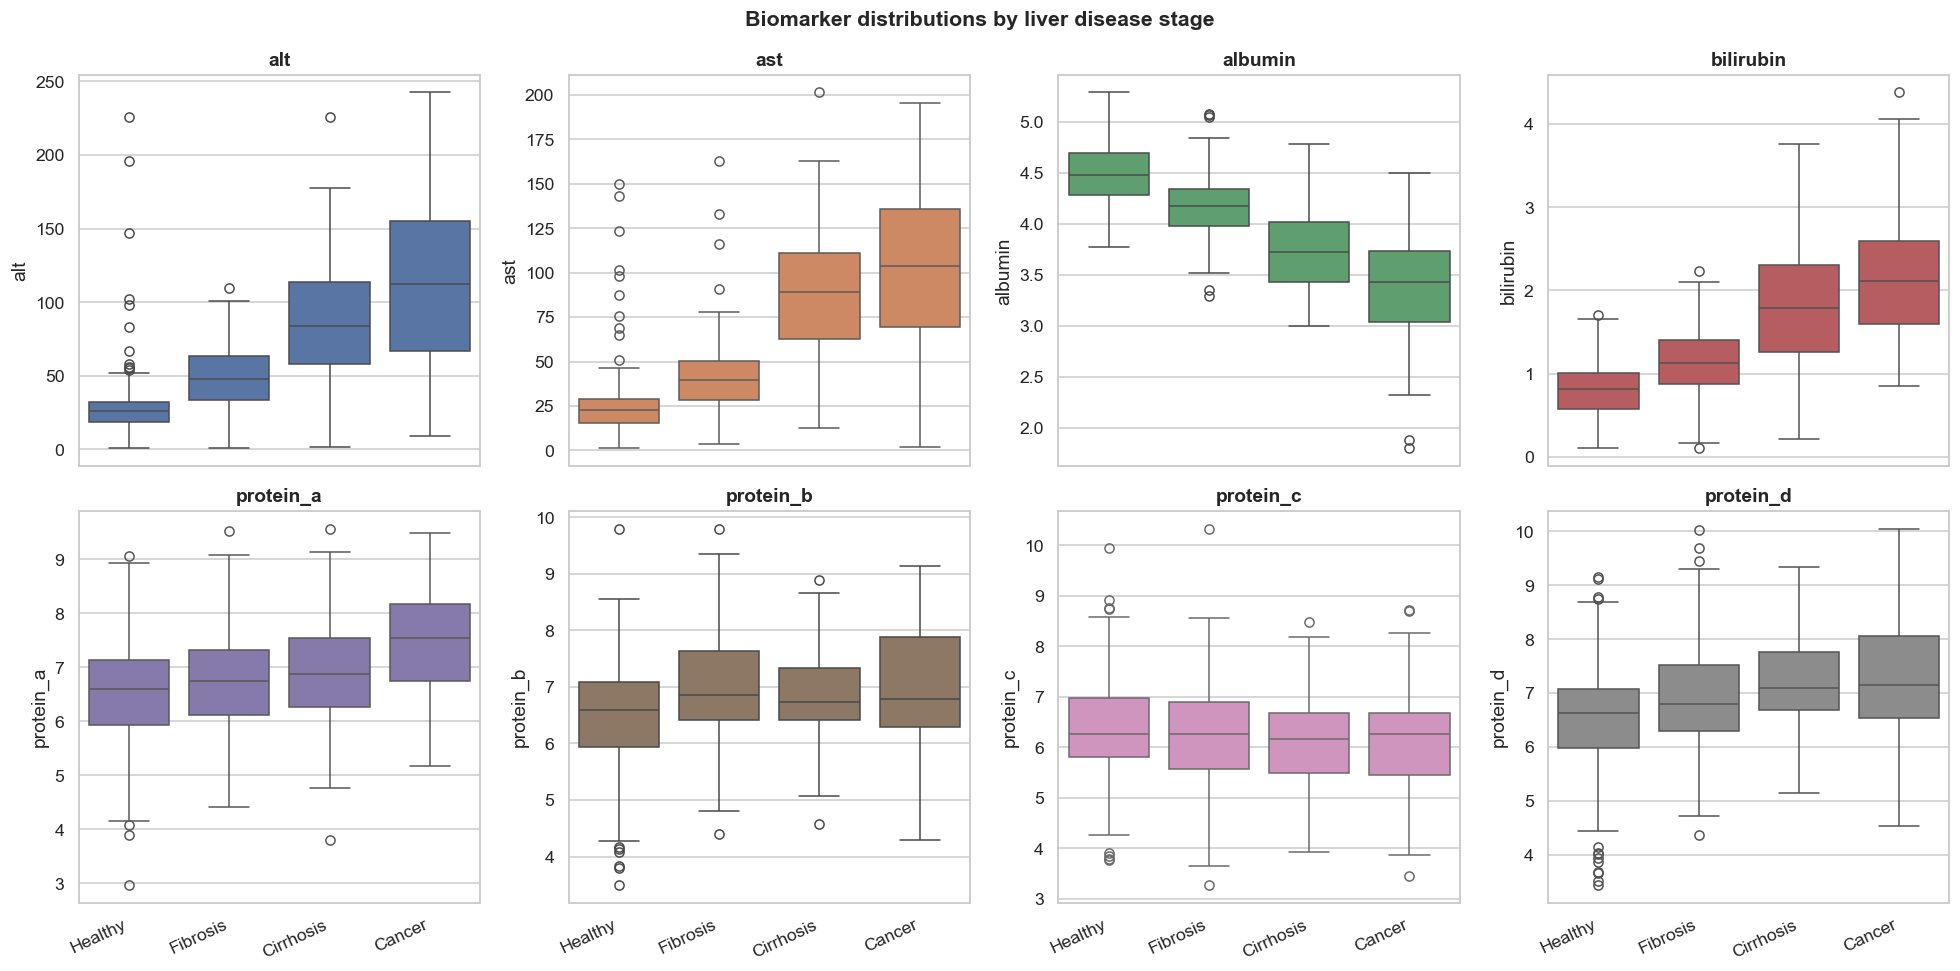

In [14]:
colors = ["#4C72B0","#DD8452","#55A868","#C44E52",
          "#8172B2","#937860","#DA8BC3","#8C8C8C"]
fig, axes = plt.subplots(2, 4, figsize=(18, 9), sharex=True)
axes = axes.flatten()
for i, var in enumerate(BIOMARKERS):
    sns.boxplot(data=dfs, x="liver_status", y=var, ax=axes[i], color=colors[i])
    axes[i].set_title(var, fontweight="bold")
    axes[i].set_xticklabels(
        [STAGE_LABELS[k] for k in sorted(dfs["liver_status"].unique())],
        rotation=25, ha="right")
    axes[i].set_xlabel("")
plt.suptitle("Biomarker distributions by liver disease stage",
             fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

C:\Users\henri-philippe.konan\AppData\Local\Temp\ipykernel_11544\3361073736.py:7: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(
C:\Users\henri-philippe.konan\AppData\Local\Temp\ipykernel_11544\3361073736.py:7: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(


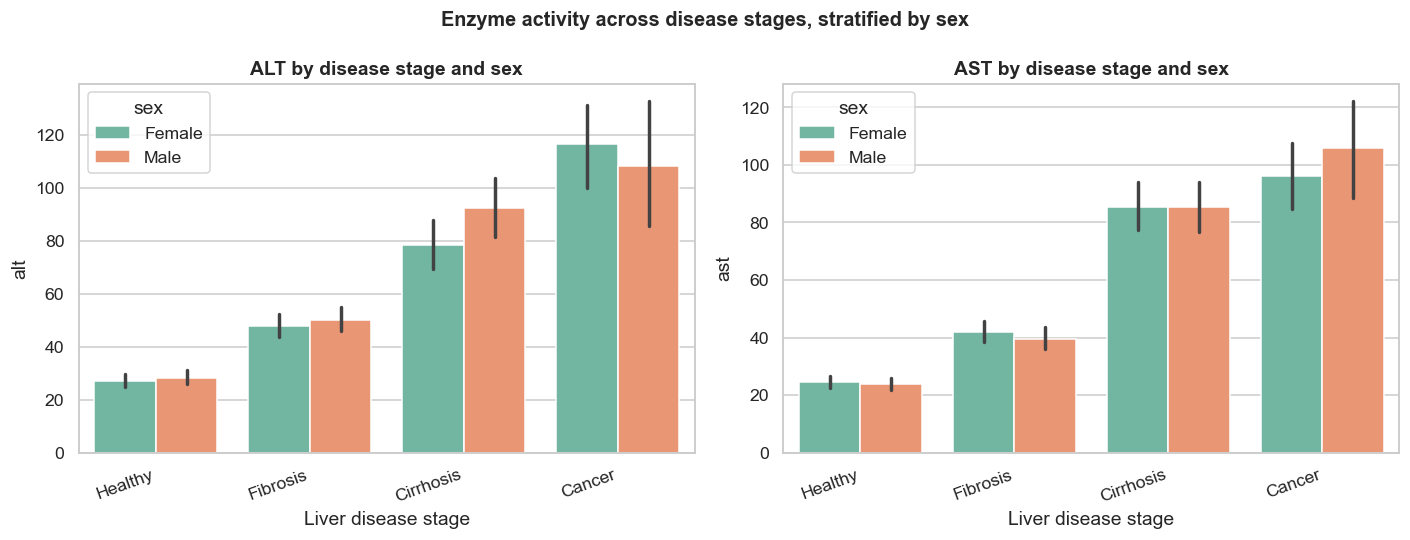

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
for ax, enzyme in zip(axes, ["alt", "ast"]):
    sns.barplot(data=dfs, x="liver_status", y=enzyme,
                hue="sex", ax=ax, palette="Set2")
    ax.set_title(f"{enzyme.upper()} by disease stage and sex", fontweight="bold")
    ax.set_xlabel("Liver disease stage")
    ax.set_xticklabels(
        [STAGE_LABELS[k] for k in sorted(dfs["liver_status"].unique())],
        rotation=20, ha="right")
plt.suptitle("Enzyme activity across disease stages, stratified by sex",
             fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

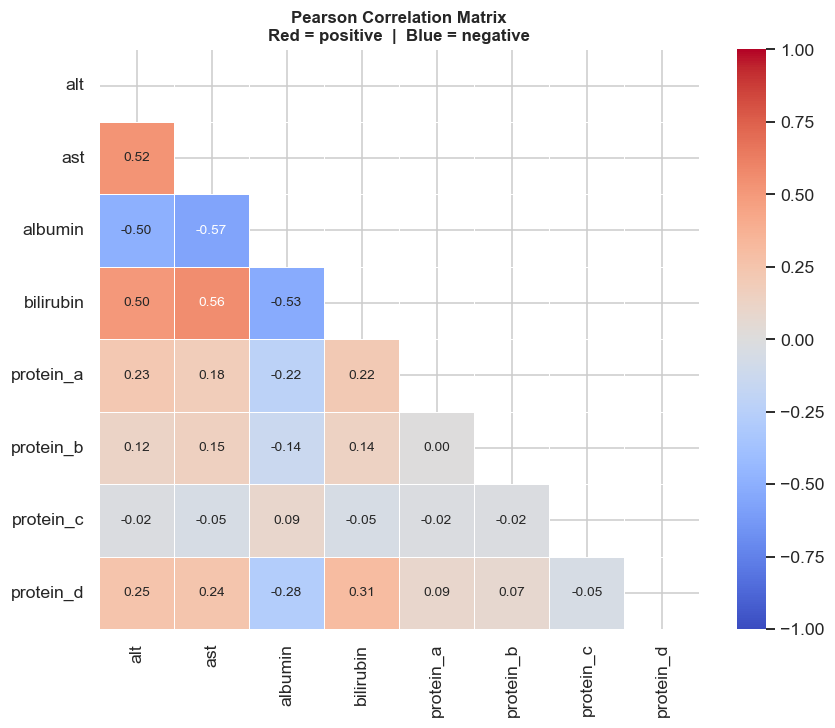

In [16]:
plot_correlation_heatmap(dfs, BIOMARKERS)

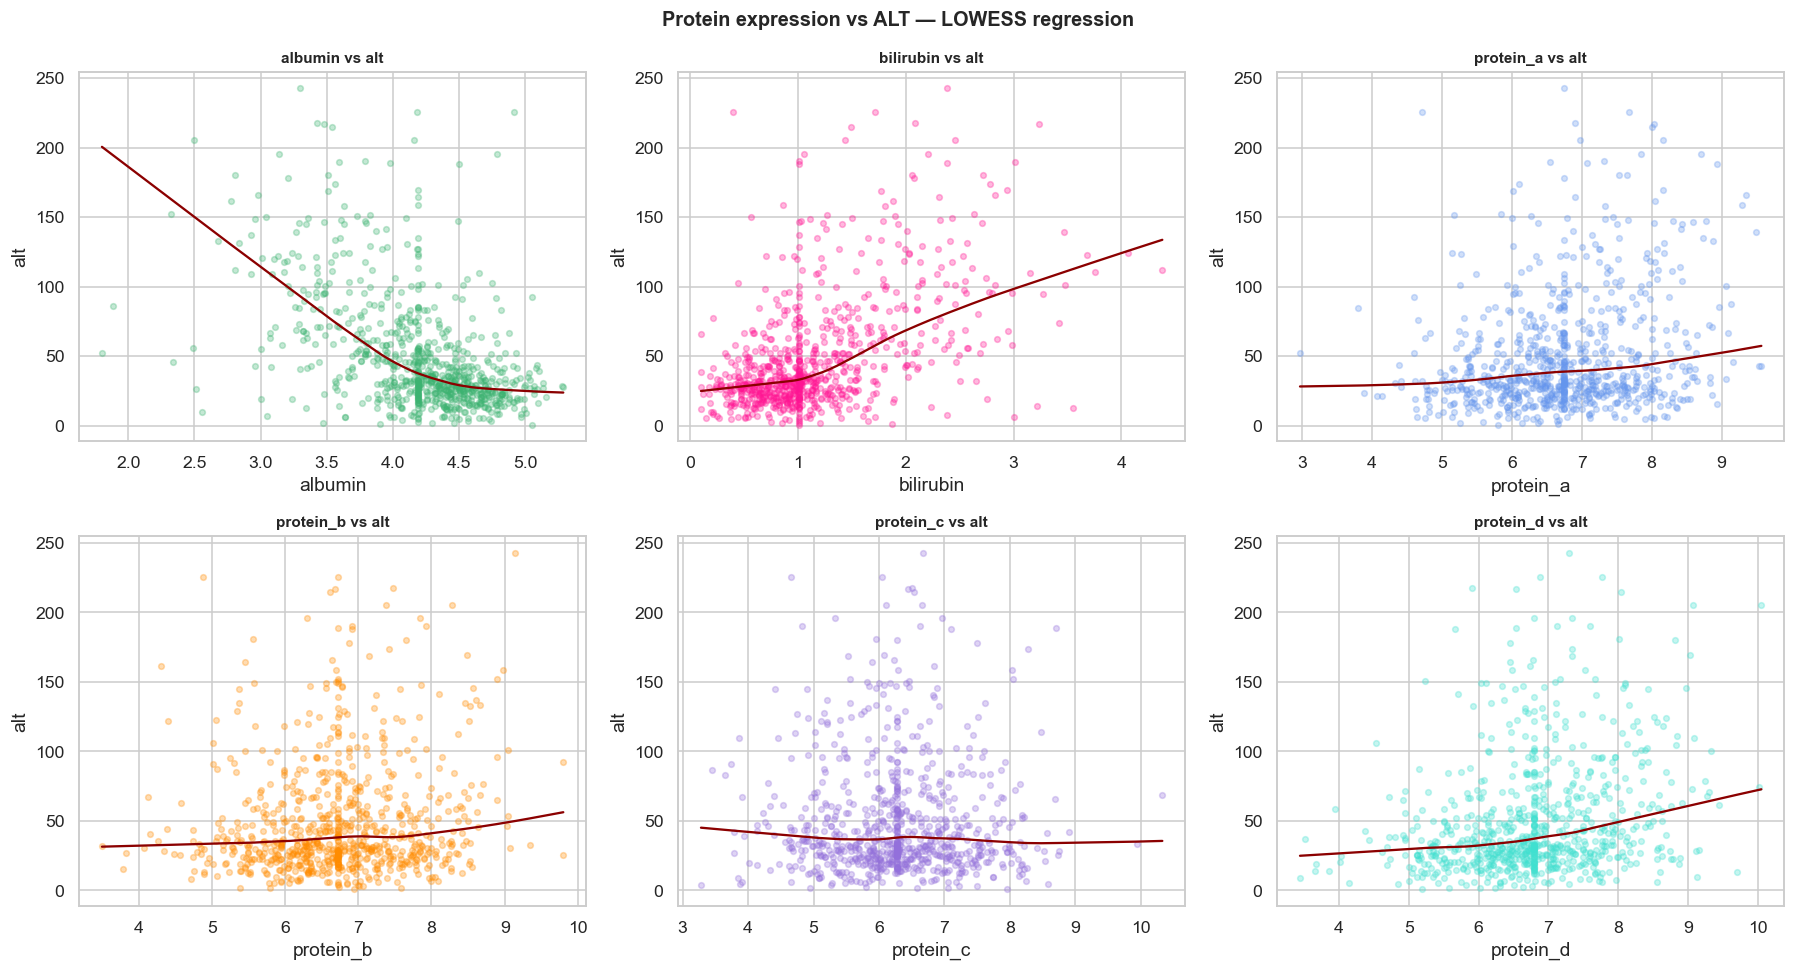

In [17]:
PROTEIN_PREDICTORS = ["albumin", "bilirubin",
                      "protein_a", "protein_b", "protein_c", "protein_d"]
plot_regplots(dfs, PROTEIN_PREDICTORS, target="alt",
              title="Protein expression vs ALT — LOWESS regression")

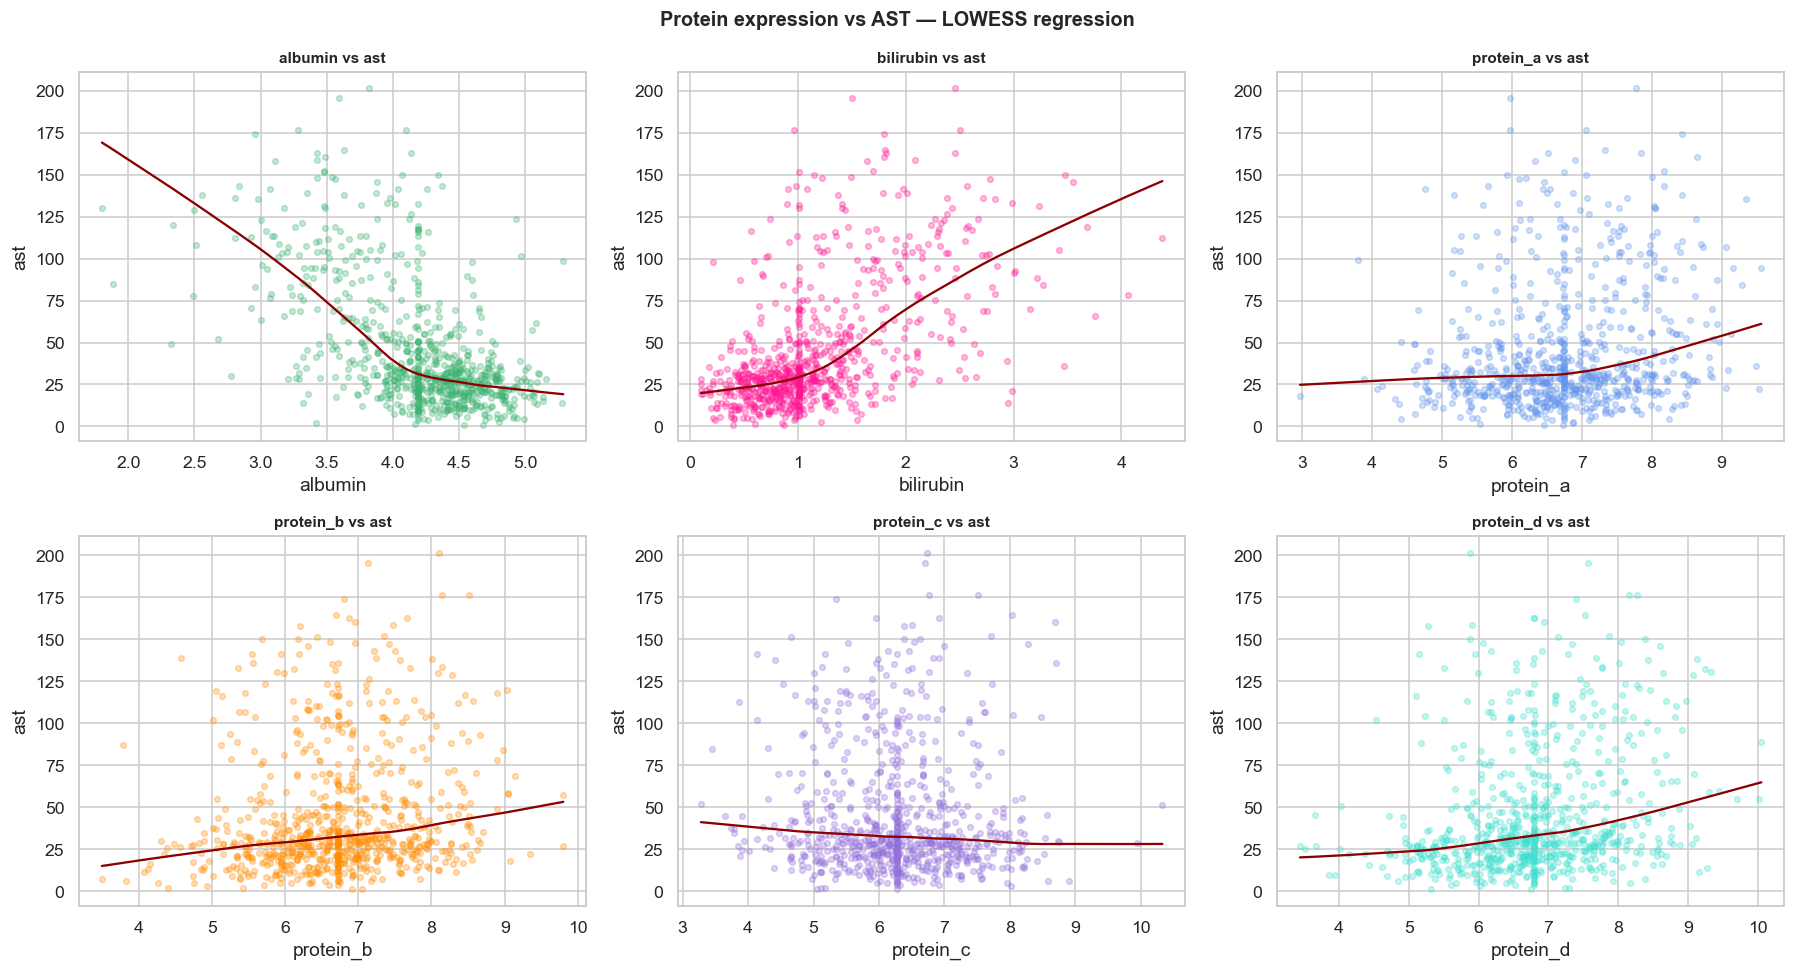

In [18]:
plot_regplots(dfs, PROTEIN_PREDICTORS, target="ast",
              title="Protein expression vs AST — LOWESS regression")

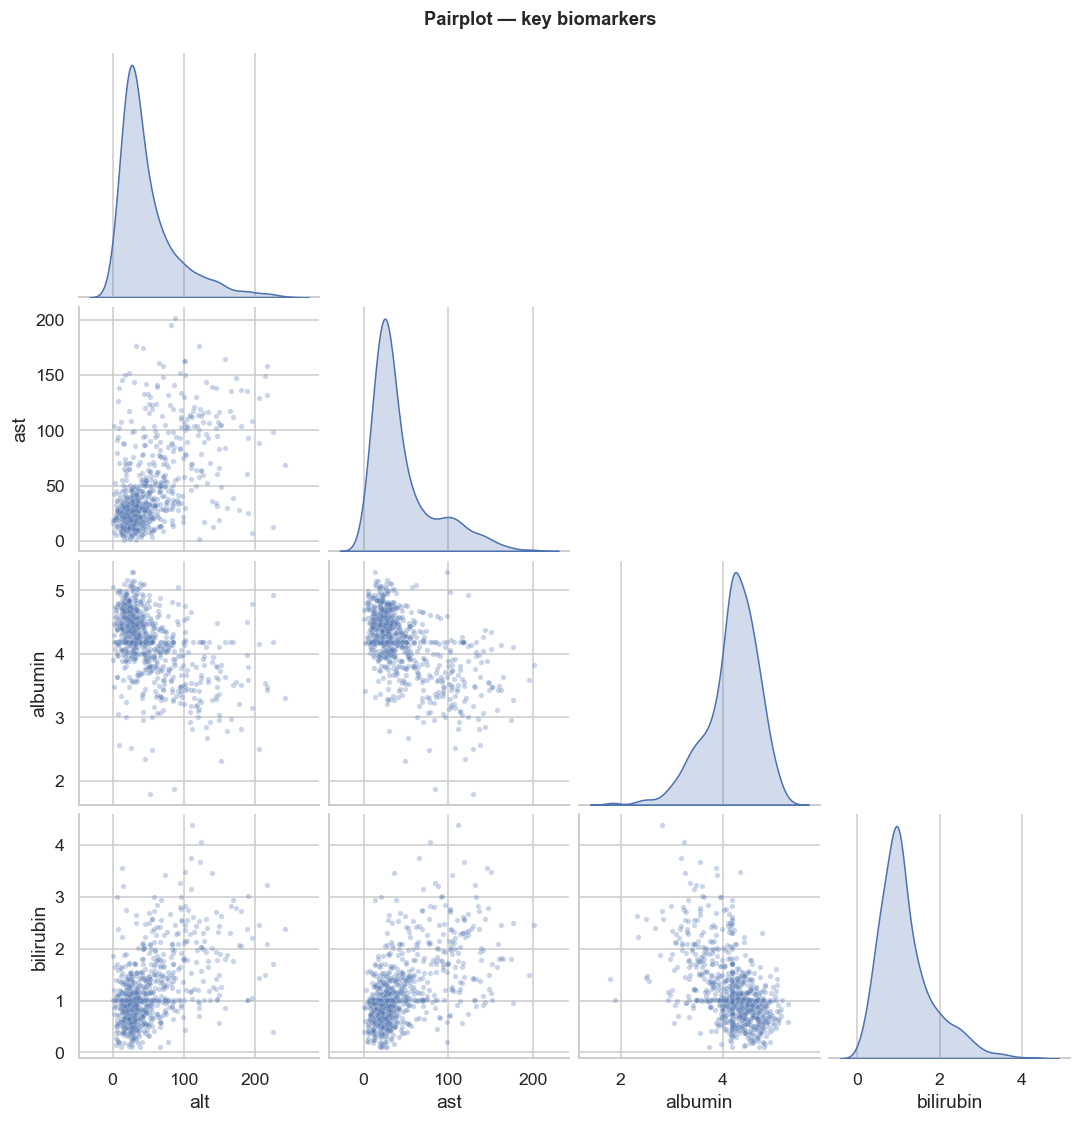

In [19]:
g = sns.pairplot(
    dfs[["alt", "ast", "albumin", "bilirubin"]],
    diag_kind="kde", corner=True,
    plot_kws={"alpha": 0.3, "s": 12})
g.fig.suptitle("Pairplot — key biomarkers", y=1.02,
               fontsize=12, fontweight="bold")
plt.show()

In [20]:
print("Mean biomarker values by liver disease stage:")
dfs.groupby("liver_status")[BIOMARKERS].mean().round(2)

Mean biomarker values by liver disease stage:


,alt,ast,albumin,bilirubin,protein_a,protein_b,protein_c,protein_d
liver_status,,,,,,,,
0,27.58,24.06,4.50,0.80,6.54,6.51,6.36,6.52
1,48.98,40.86,4.17,1.14,6.73,6.96,6.22,6.91
2,84.80,85.51,3.73,1.82,6.94,6.83,6.10,7.20
3,113.50,99.86,3.39,2.15,7.51,6.98,6.17,7.25


---
## 3. Statistical Modeling — ALT

### Why log-transform?

ALT is strictly positive and right-skewed. The log1p transformation (`log(1+ALT)`)
linearizes its relationship with predictors and reduces heteroscedasticity, making
OLS assumptions more defensible.

### Candidate predictors

| Predictor | Expected direction | Biological rationale |
|---|---|---|
| `albumin` | Negative | Synthesized by hepatocytes; lower when liver is damaged |
| `bilirubin` | Positive | By-product of RBC turnover; elevated in liver dysfunction |
| `ast` | Positive | Both enzymes co-released during hepatocyte injury |
| `sex` | Unclear | Tested as potential confounder |

### Model-building strategy

| Model | Formula |
|---|---|
| M1 | `log_alt ~ albumin` |
| M2 | `log_alt ~ albumin + bilirubin` |
| M3 | `log_alt ~ albumin + bilirubin + ast` |
| M4 | `log_alt ~ albumin + bilirubin + ast + C(sex)` (full model) |

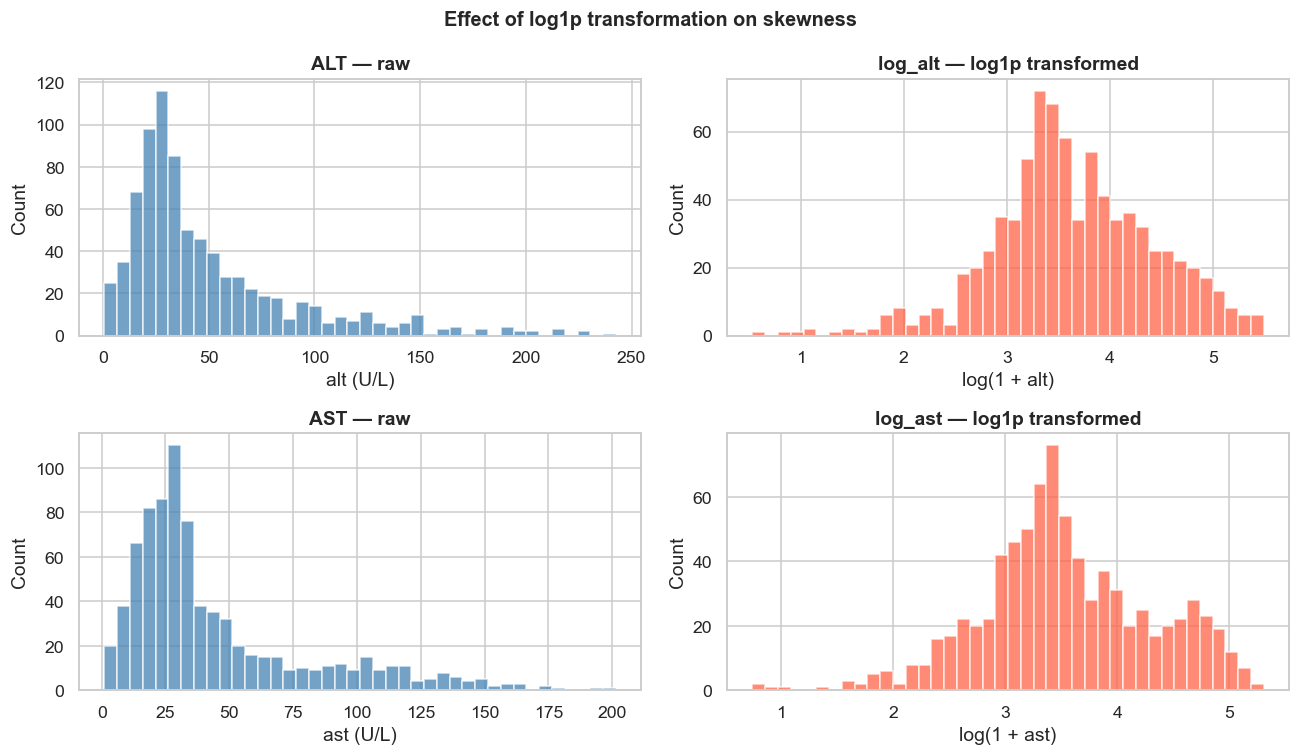

In [21]:
dfs["log_alt"]       = np.log1p(dfs["alt"])
dfs["log_ast"]       = np.log1p(dfs["ast"])
dfs["log_bilirubin"] = np.log1p(dfs["bilirubin"])

# 2x2 grid: rows = enzyme, columns = raw vs log1p (separate axes, separate scales).
fig, axes = plt.subplots(2, 2, figsize=(12, 7))
for row, (raw, log_col) in enumerate(zip(["alt", "ast"], ["log_alt", "log_ast"])):
    axes[row, 0].hist(dfs[raw], bins=40, color="steelblue", alpha=0.75, edgecolor="white")
    axes[row, 0].set_title(f"{raw.upper()} — raw", fontweight="bold")
    axes[row, 0].set_xlabel(f"{raw} (U/L)")
    axes[row, 0].set_ylabel("Count")

    axes[row, 1].hist(dfs[log_col], bins=40, color="tomato", alpha=0.75, edgecolor="white")
    axes[row, 1].set_title(f"{log_col} — log1p transformed", fontweight="bold")
    axes[row, 1].set_xlabel(f"log(1 + {raw})")
    axes[row, 1].set_ylabel("Count")

plt.suptitle("Effect of log1p transformation on skewness",
             fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

In [22]:
candidates = ["albumin", "bilirubin", "ast", "age", "bmi"]
print("Univariate OLS screening — log_alt\n")
print(f"{'Predictor':<14} {'Coef':>9} {'p-value':>10} {'R²':>8}")
print("-" * 45)
for v in candidates:
    m = smf.ols(f"log_alt ~ {v}", data=dfs).fit()
    print(f"{v:<14} {m.params[v]:>9.4f} {m.pvalues[v]:>10.4f} {m.rsquared:>8.3f}")

Univariate OLS screening — log_alt

Predictor           Coef    p-value       R²
---------------------------------------------
albumin          -0.7047     0.0000    0.214
bilirubin         0.5259     0.0000    0.201
ast               0.0097     0.0000    0.214
age              -0.0008     0.6564    0.000
bmi              -0.0100     0.1562    0.003


In [23]:
model_alt1 = smf.ols("log_alt ~ albumin", data=dfs).fit()
print(model_alt1.summary())

                            OLS Regression Results                            
Dep. Variable:                log_alt   R-squared:                       0.214
Model:                            OLS   Adj. R-squared:                  0.213
Method:                 Least Squares   F-statistic:                     216.9
Date:                Sat, 16 May 2026   Prob (F-statistic):           1.31e-43
Time:                        20:36:01   Log-Likelihood:                -834.74
No. Observations:                 800   AIC:                             1673.
Df Residuals:                     798   BIC:                             1683.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept      6.5975      0.202     32.653      0.0

In [24]:
model_alt2 = smf.ols("log_alt ~ albumin + bilirubin", data=dfs).fit()
print(model_alt2.summary())

                            OLS Regression Results                            
Dep. Variable:                log_alt   R-squared:                       0.272
Model:                            OLS   Adj. R-squared:                  0.270
Method:                 Least Squares   F-statistic:                     148.6
Date:                Sat, 16 May 2026   Prob (F-statistic):           1.40e-55
Time:                        20:36:01   Log-Likelihood:                -804.15
No. Observations:                 800   AIC:                             1614.
Df Residuals:                     797   BIC:                             1628.
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept      5.2511      0.258     20.365      0.0

In [25]:
model_alt3 = smf.ols("log_alt ~ albumin + bilirubin + ast", data=dfs).fit()
print(model_alt3.summary())

                            OLS Regression Results                            
Dep. Variable:                log_alt   R-squared:                       0.299
Model:                            OLS   Adj. R-squared:                  0.297
Method:                 Least Squares   F-statistic:                     113.3
Date:                Sat, 16 May 2026   Prob (F-statistic):           4.37e-61
Time:                        20:36:01   Log-Likelihood:                -788.72
No. Observations:                 800   AIC:                             1585.
Df Residuals:                     796   BIC:                             1604.
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept      4.6296      0.276     16.751      0.0

In [26]:
model_alt4 = smf.ols("log_alt ~ albumin + bilirubin + ast + C(sex)", data=dfs).fit()
print(model_alt4.summary())

                            OLS Regression Results                            
Dep. Variable:                log_alt   R-squared:                       0.299
Model:                            OLS   Adj. R-squared:                  0.296
Method:                 Least Squares   F-statistic:                     84.92
Date:                Sat, 16 May 2026   Prob (F-statistic):           4.63e-60
Time:                        20:36:01   Log-Likelihood:                -788.63
No. Observations:                 800   AIC:                             1587.
Df Residuals:                     795   BIC:                             1611.
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                     coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------
Intercept          4.6193      0.278     16.

In [27]:
alt_rows = [
    model_summary_row(model_alt1, "M1: albumin",      ["albumin"]),
    model_summary_row(model_alt2, "M2: +bilirubin",   ["albumin", "bilirubin"]),
    model_summary_row(model_alt3, "M3: +ast",         ["albumin", "bilirubin", "ast"]),
    model_summary_row(model_alt4, "M4: +sex (full)",  ["albumin", "bilirubin", "ast"]),
]
pd.DataFrame(alt_rows).set_index("model")

,R²,adj. R²,AIC,albumin,bilirubin,ast
model,,,,,,
M1: albumin,0.214,0.213,1673.5,-0.705*,NaN,NaN
M2: +bilirubin,0.272,0.270,1614.3,-0.476*,0.332*,NaN
M3: +ast,0.299,0.297,1585.4,-0.352*,0.241*,0.005*
M4: +sex (full),0.299,0.296,1587.3,-0.352*,0.242*,0.005*


**Interpretation — ALT models**

- **Albumin** is the strongest single predictor (M1 R² = 0.214). Its negative coefficient
  reflects preserved hepatocyte synthetic function: when albumin is high, the liver is
  healthy, so ALT tends to be lower.
- Adding **bilirubin** raises R² to 0.272. Both effects remain highly significant (p < 0.001).
- Adding **AST** raises R² to 0.299: co-release during hepatocyte injury explains the
  strong positive association.
- **Sex** does not add predictive power (p ≈ 0.67, ΔR² = 0): gender differences in
  enzyme activity disappear once the biochemical markers are controlled for.

### Diagnostics — ALT full model (M4)

Three checks are performed:
1. **Residuals vs Fitted + Normal Q-Q** — visual inspection of homoscedasticity and normality.
2. **Breusch-Pagan test** — formal test for heteroscedasticity; HC3 robust SE are applied if p < 0.05.
3. **Variance Inflation Factors (VIF)** — detects multicollinearity among predictors.
   Thresholds: VIF < 5 acceptable · 5–10 moderate concern · > 10 severe.

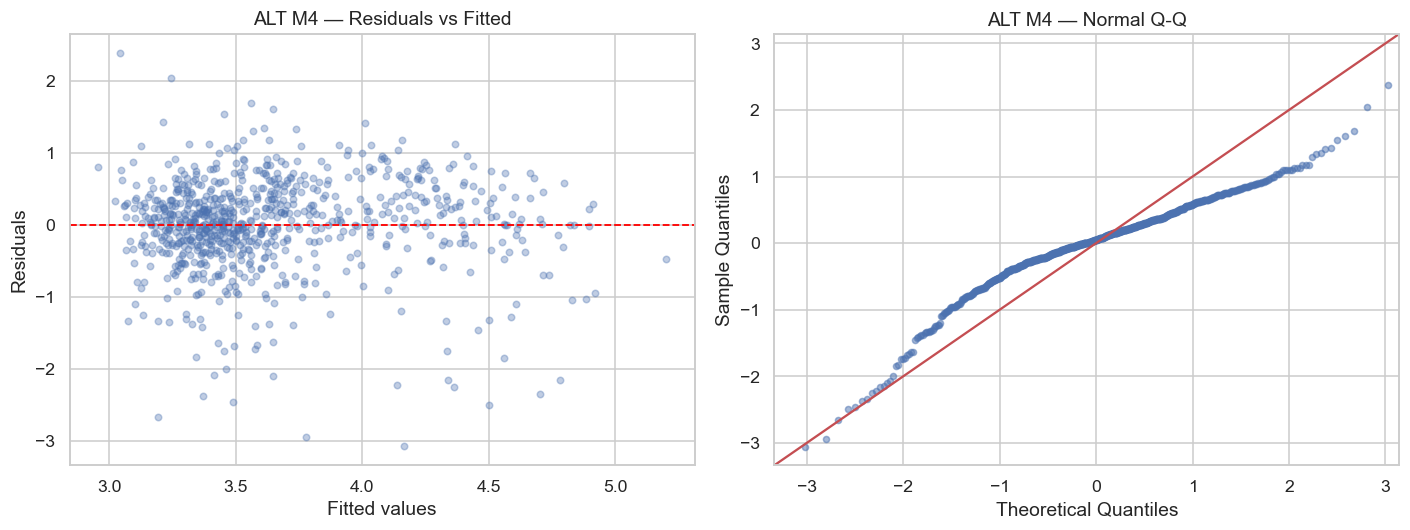

Breusch-Pagan test (ALT M4):
  LM statistic = 8.0899   p = 0.0883
  → No significant heteroscedasticity (p ≥ 0.05).


In [28]:
ols_diagnostics(model_alt4, label="ALT M4")

In [29]:
# HC3 robust SE are shown as a precautionary robustness check.
# If Breusch-Pagan p < 0.05 above, they are required; otherwise they confirm
# that standard SE conclusions hold under mild violations.
model_alt4_robust = smf.ols(
    "log_alt ~ albumin + bilirubin + ast + C(sex)", data=dfs
).fit(cov_type="HC3")
print(model_alt4_robust.summary())

                            OLS Regression Results                            
Dep. Variable:                log_alt   R-squared:                       0.299
Model:                            OLS   Adj. R-squared:                  0.296
Method:                 Least Squares   F-statistic:                     67.43
Date:                Sat, 16 May 2026   Prob (F-statistic):           3.75e-49
Time:                        20:36:01   Log-Likelihood:                -788.63
No. Observations:                 800   AIC:                             1587.
Df Residuals:                     795   BIC:                             1611.
Df Model:                           4                                         
Covariance Type:                  HC3                                         
                     coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------
Intercept          4.6193      0.326     14.

In [30]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

exog       = model_alt4.model.exog
exog_names = model_alt4.model.exog_names

vif_rows = [
    {"Variable": name, "VIF": round(variance_inflation_factor(exog, i), 2)}
    for i, name in enumerate(exog_names)
    if name != "Intercept"
]
vif_df = pd.DataFrame(vif_rows)
print("Variance Inflation Factors — ALT M4\n")
print(vif_df.to_string(index=False))

Variance Inflation Factors — ALT M4

      Variable  VIF
C(sex)[T.Male] 1.00
       albumin 1.63
     bilirubin 1.61
           ast 1.71


**VIF interpretation — ALT model**

| VIF range | Meaning |
|---|---|
| < 5 | Acceptable — no multicollinearity concern |
| 5 – 10 | Moderate — coefficients may be somewhat unstable |
| > 10 | Severe — consider removing or combining predictors |

**Expected findings**: albumin and bilirubin are both markers of liver function, so moderate
correlation (VIF 2–5) is expected. AST may show a slightly higher VIF given its strong
pairwise correlation with ALT. Elevated VIF does not invalidate predictions but means
individual coefficients depend on what else is in the model and should be interpreted
in that context.

**Diagnostic summary — ALT**

| Check | Result |
|---|---|
| Residuals vs Fitted | No strong curvature; verify visually above |
| Breusch-Pagan test | Read p-value from output above: if p < 0.05 → heteroscedasticity present |
| Normal Q-Q | Residuals approximately normal; check tail behaviour above |
| Robust model | HC3 SE shown below as a robustness check regardless of Breusch-Pagan result |

Coefficient estimates are identical in both models; only standard errors and p-values differ.

---
## 4. Statistical Modeling — AST

The same incremental framework is applied to `log_ast`.

The predictor set mirrors Section 3, with one swap: AST is now the **outcome variable**,
so it cannot appear on the right-hand side. **ALT** takes its place, which is biologically
consistent — both enzymes are co-released from damaged hepatocytes, so each predicts
the other once albumin and bilirubin are controlled for.

| Model | Formula |
|---|---|
| M1 | `log_ast ~ albumin` |
| M2 | `log_ast ~ albumin + bilirubin` |
| M3 | `log_ast ~ albumin + bilirubin + alt` |
| M4 | `log_ast ~ albumin + bilirubin + alt + C(sex)` (full model) |

In [31]:
candidates_ast = ["albumin", "bilirubin", "alt", "age", "bmi"]
print("Univariate OLS screening — log_ast\n")
print(f"{'Predictor':<14} {'Coef':>9} {'p-value':>10} {'R²':>8}")
print("-" * 45)
for v in candidates_ast:
    m = smf.ols(f"log_ast ~ {v}", data=dfs).fit()
    print(f"{v:<14} {m.params[v]:>9.4f} {m.pvalues[v]:>10.4f} {m.rsquared:>8.3f}")

Univariate OLS screening — log_ast

Predictor           Coef    p-value       R²
---------------------------------------------
albumin          -0.8018     0.0000    0.284
bilirubin         0.6214     0.0000    0.288
alt               0.0088     0.0000    0.226
age              -0.0001     0.9631    0.000
bmi               0.0013     0.8474    0.000


In [32]:
model_ast1 = smf.ols("log_ast ~ albumin", data=dfs).fit()
print(model_ast1.summary())

                            OLS Regression Results                            
Dep. Variable:                log_ast   R-squared:                       0.284
Model:                            OLS   Adj. R-squared:                  0.283
Method:                 Least Squares   F-statistic:                     316.3
Date:                Sat, 16 May 2026   Prob (F-statistic):           7.42e-60
Time:                        20:36:01   Log-Likelihood:                -787.09
No. Observations:                 800   AIC:                             1578.
Df Residuals:                     798   BIC:                             1588.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept      6.9049      0.190     36.272      0.0

In [33]:
model_ast2 = smf.ols("log_ast ~ albumin + bilirubin", data=dfs).fit()
print(model_ast2.summary())

                            OLS Regression Results                            
Dep. Variable:                log_ast   R-squared:                       0.374
Model:                            OLS   Adj. R-squared:                  0.373
Method:                 Least Squares   F-statistic:                     238.5
Date:                Sat, 16 May 2026   Prob (F-statistic):           6.81e-82
Time:                        20:36:01   Log-Likelihood:                -733.04
No. Observations:                 800   AIC:                             1472.
Df Residuals:                     797   BIC:                             1486.
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept      5.2428      0.236     22.224      0.0

In [34]:
model_ast3 = smf.ols("log_ast ~ albumin + bilirubin + alt", data=dfs).fit()
print(model_ast3.summary())

                            OLS Regression Results                            
Dep. Variable:                log_ast   R-squared:                       0.398
Model:                            OLS   Adj. R-squared:                  0.395
Method:                 Least Squares   F-statistic:                     175.2
Date:                Sat, 16 May 2026   Prob (F-statistic):           3.21e-87
Time:                        20:36:01   Log-Likelihood:                -717.81
No. Observations:                 800   AIC:                             1444.
Df Residuals:                     796   BIC:                             1462.
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept      4.7713      0.247     19.344      0.0

In [35]:
model_ast4 = smf.ols("log_ast ~ albumin + bilirubin + alt + C(sex)", data=dfs).fit()
print(model_ast4.summary())

                            OLS Regression Results                            
Dep. Variable:                log_ast   R-squared:                       0.399
Model:                            OLS   Adj. R-squared:                  0.396
Method:                 Least Squares   F-statistic:                     131.9
Date:                Sat, 16 May 2026   Prob (F-statistic):           2.23e-86
Time:                        20:36:01   Log-Likelihood:                -717.07
No. Observations:                 800   AIC:                             1444.
Df Residuals:                     795   BIC:                             1468.
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                     coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------
Intercept          4.7931      0.247     19.

In [36]:
ast_rows = [
    model_summary_row(model_ast1, "M1: albumin",      ["albumin"]),
    model_summary_row(model_ast2, "M2: +bilirubin",   ["albumin", "bilirubin"]),
    model_summary_row(model_ast3, "M3: +alt",         ["albumin", "bilirubin", "alt"]),
    model_summary_row(model_ast4, "M4: +sex (full)",  ["albumin", "bilirubin", "alt"]),
]
pd.DataFrame(ast_rows).set_index("model")

,R²,adj. R²,AIC,albumin,bilirubin,alt
model,,,,,,
M1: albumin,0.284,0.283,1578.2,-0.802*,NaN,NaN
M2: +bilirubin,0.374,0.373,1472.1,-0.520*,0.410*,NaN
M3: +alt,0.398,0.395,1443.6,-0.429*,0.339*,0.003*
M4: +sex (full),0.399,0.396,1444.1,-0.427*,0.337*,0.003*


### Diagnostics — AST full model (M4)

Three checks are performed:
1. **Residuals vs Fitted + Normal Q-Q** — visual inspection of homoscedasticity and normality.
2. **Breusch-Pagan test** — formal test for heteroscedasticity; HC3 robust SE are applied if p < 0.05.
3. **Variance Inflation Factors (VIF)** — detects multicollinearity among predictors.
   Thresholds: VIF < 5 acceptable · 5–10 moderate concern · > 10 severe.

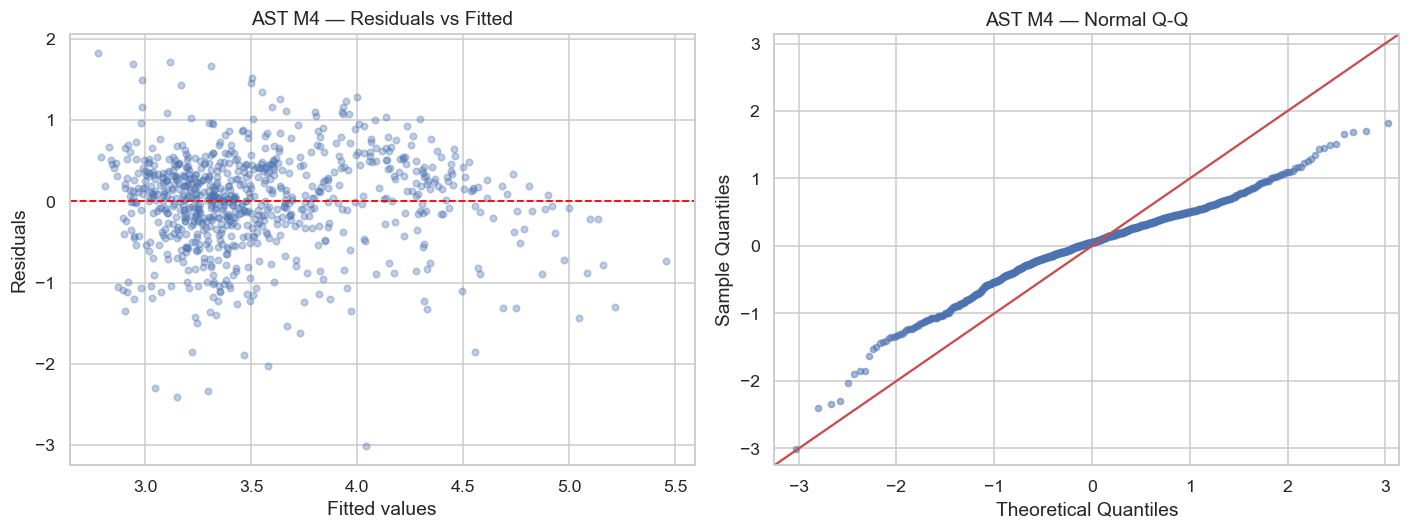

Breusch-Pagan test (AST M4):
  LM statistic = 5.4645   p = 0.2429
  → No significant heteroscedasticity (p ≥ 0.05).


In [37]:
ols_diagnostics(model_ast4, label="AST M4")

In [38]:
# HC3 robust SE as a robustness check (required if Breusch-Pagan p < 0.05 above).
model_ast4_robust = smf.ols(
    "log_ast ~ albumin + bilirubin + alt + C(sex)", data=dfs
).fit(cov_type="HC3")
print(model_ast4_robust.summary())

                            OLS Regression Results                            
Dep. Variable:                log_ast   R-squared:                       0.399
Model:                            OLS   Adj. R-squared:                  0.396
Method:                 Least Squares   F-statistic:                     117.0
Date:                Sat, 16 May 2026   Prob (F-statistic):           1.86e-78
Time:                        20:36:01   Log-Likelihood:                -717.07
No. Observations:                 800   AIC:                             1444.
Df Residuals:                     795   BIC:                             1468.
Df Model:                           4                                         
Covariance Type:                  HC3                                         
                     coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------
Intercept          4.7931      0.256     18.

In [39]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

exog       = model_ast4.model.exog
exog_names = model_ast4.model.exog_names

vif_rows = [
    {"Variable": name, "VIF": round(variance_inflation_factor(exog, i), 2)}
    for i, name in enumerate(exog_names)
    if name != "Intercept"
]
vif_df = pd.DataFrame(vif_rows)
print("Variance Inflation Factors — AST M4\n")
print(vif_df.to_string(index=False))

Variance Inflation Factors — AST M4

      Variable  VIF
C(sex)[T.Male] 1.00
       albumin 1.55
     bilirubin 1.55
           alt 1.49


**VIF interpretation — AST model**

| VIF range | Meaning |
|---|---|
| < 5 | Acceptable — no multicollinearity concern |
| 5 – 10 | Moderate — coefficients may be somewhat unstable |
| > 10 | Severe — consider removing or combining predictors |

**Expected findings**: albumin and bilirubin are both markers of liver synthetic and excretory
function, so moderate correlation (VIF 2–5) is expected and biologically meaningful.
ALT may show a slightly higher VIF given its strong pairwise correlation with AST.
Elevated VIF does not invalidate the model's predictions but suggests that individual
coefficients should be interpreted with caution (their values depend on what else is in
the model).

---
## 5. Enzyme Activity vs Liver Disease Stage

We test whether log_alt and log_ast differ significantly across the four
disease stages using:

1. **Levene's test** — checks variance homogeneity (H₀: equal variances).
2. **One-way ANOVA** — tests for any significant group difference (H₀: equal means).
3. **Tukey HSD** — identifies which specific stage pairs differ after a significant ANOVA.
4. **OLS trend** — quantifies the average change per disease stage.
5. **Rank correlations** — Spearman ρ and Kendall τ with liver_status.

C:\Users\henri-philippe.konan\AppData\Local\Temp\ipykernel_11544\231471142.py:4: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(
C:\Users\henri-philippe.konan\AppData\Local\Temp\ipykernel_11544\231471142.py:4: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(


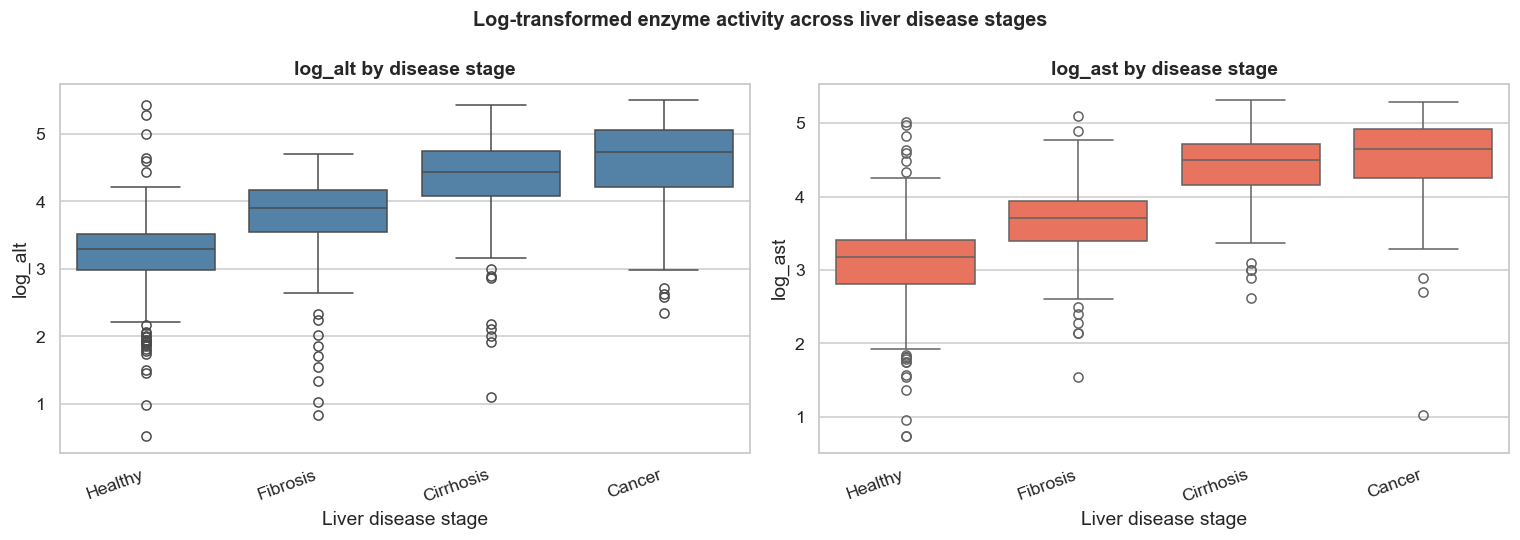

In [40]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, target, col in zip(axes, ["log_alt", "log_ast"], ["steelblue", "tomato"]):
    sns.boxplot(x="liver_status", y=target, data=dfs, color=col, ax=ax)
    ax.set_xticklabels(
        [STAGE_LABELS[k] for k in sorted(dfs["liver_status"].unique())],
        rotation=20, ha="right")
    ax.set_title(f"{target} by disease stage", fontweight="bold")
    ax.set_xlabel("Liver disease stage")
plt.suptitle("Log-transformed enzyme activity across liver disease stages",
             fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

In [41]:
for target in ["log_alt", "log_ast"]:
    print(f"\n--- {target} by stage ---")
    tbl = dfs.groupby("liver_status")[target].agg(["mean", "std", "var"]).round(3)
    tbl.index = [STAGE_LABELS[i] for i in tbl.index]
    print(tbl)


--- log_alt by stage ---
            mean    std    var
Healthy    3.216  0.530  0.281
Fibrosis   3.770  0.631  0.398
Cirrhosis  4.279  0.701  0.492
Cancer     4.546  0.725  0.525

--- log_ast by stage ---
            mean    std    var
Healthy    3.080  0.548  0.301
Fibrosis   3.628  0.486  0.237
Cirrhosis  4.355  0.504  0.254
Cancer     4.462  0.672  0.452


In [42]:
print("Levene's test for variance homogeneity:")
for target in ["log_alt", "log_ast"]:
    groups = [g[target].dropna().values for _, g in dfs.groupby("liver_status")]
    stat, p = stats.levene(*groups)
    print(f"  {target}: W = {stat:.3f}, p = {p:.4f}")

Levene's test for variance homogeneity:
  log_alt: W = 3.443, p = 0.0164
  log_ast: W = 0.871, p = 0.4558


In [43]:
print("One-way ANOVA:")
for target in ["log_alt", "log_ast"]:
    groups = [g[target].dropna().values for _, g in dfs.groupby("liver_status")]
    F, p = stats.f_oneway(*groups)
    print(f"  {target}: F = {F:.3f}, p = {p:.2e}")

One-way ANOVA:
  log_alt: F = 172.874, p = 2.71e-86
  log_ast: F = 268.881, p = 1.75e-120


**Levene test decision rule**

| Variable | Levene p | Variance homogeneity | Appropriate test |
|---|---|---|---|
| `log_alt` | 0.016 | ❌ Rejected (p < 0.05) | **Welch ANOVA** |
| `log_ast` | 0.456 | ✓ Assumed (p ≥ 0.05) | Standard ANOVA |

`log_alt` violates the equal-variance assumption of the standard ANOVA.
Welch's ANOVA relaxes this assumption by weighting group means by their
precision (n / variance) instead of assuming a common within-group variance.

In [44]:
# Welch ANOVA for log_alt only (Levene p < 0.05 → unequal variances).
import pingouin as pg

welch_result = pg.welch_anova(dv="log_alt", between="liver_status", data=dfs)
print("Welch ANOVA — log_alt\n")
print(welch_result.to_string(index=False))

p_welch = welch_result["p_unc"].values[0]
f_welch = welch_result["F"].values[0]
print(f"\nF = {f_welch:.3f}, p = {p_welch:.2e}")
if p_welch < 0.05:
    print("→ At least one disease stage has a significantly different mean log_alt.")
    print("  Proceed to Games-Howell post-hoc (appropriate when variances are unequal).")

Welch ANOVA — log_alt

      Source  ddof1      ddof2          F        p_unc      np2
liver_status      3 229.358438 153.205791 1.642907e-54 0.394503

F = 153.206, p = 1.64e-54
→ At least one disease stage has a significantly different mean log_alt.
  Proceed to Games-Howell post-hoc (appropriate when variances are unequal).


In [45]:
# Games-Howell post-hoc for log_alt: robust to unequal variances and sample sizes.
# Replaces Tukey HSD which assumes homoscedasticity.
import pingouin as pg

gh = pg.pairwise_gameshowell(dv="log_alt", between="liver_status", data=dfs)

# Replace numeric stage codes with readable labels in the A/B columns
gh["A"] = gh["A"].map(STAGE_LABELS)
gh["B"] = gh["B"].map(STAGE_LABELS)

print("Games-Howell post-hoc — log_alt\n")
print(gh.round(4).to_string(index=False))

Games-Howell post-hoc — log_alt

        A         B  mean_A  mean_B    diff     se        T       df   pval  hedges
  Healthy  Fibrosis  3.2163  3.7702 -0.5539 0.0525 -10.5512 325.4761 0.0000 -0.9799
  Healthy Cirrhosis  3.2163  4.2793 -1.0630 0.0676 -15.7346 173.4969 0.0000 -1.8448
  Healthy    Cancer  3.2163  4.5458 -1.3295 0.0877 -15.1582  89.2404 0.0000 -2.3510
 Fibrosis Cirrhosis  3.7702  4.2793 -0.5091 0.0770  -6.6104 249.5324 0.0000 -0.7701
 Fibrosis    Cancer  3.7702  4.5458 -0.7757 0.0952  -8.1486 120.0034 0.0000 -1.1751
Cirrhosis    Cancer  4.2793  4.5458 -0.2665 0.1043  -2.5565 151.2931 0.0555 -0.3741


**Post-hoc test selection**

| Variable | Levene p | Post-hoc test | Reason |
|---|---|---|---|
| `log_alt` | 0.016 | Games-Howell | Variances unequal → see Welch ANOVA cells below |
| `log_ast` | 0.456 | **Tukey HSD** | Variances equal → standard post-hoc applies |

Tukey HSD is run here for `log_ast` only.

In [46]:
# Tukey HSD for log_ast only — variances are homogeneous (Levene p = 0.456).
# log_alt uses Games-Howell post-hoc (see Welch ANOVA section below).
print("--- Tukey HSD post-hoc: log_ast ---")
tukey = pairwise_tukeyhsd(
    endog=dfs["log_ast"], groups=dfs["liver_status"], alpha=0.05)
print(tukey)

--- Tukey HSD post-hoc: log_ast ---
Multiple Comparison of Means - Tukey HSD, FWER=0.05
group1 group2 meandiff p-adj   lower  upper  reject
---------------------------------------------------
     0      1   0.5479    0.0  0.4263 0.6696   True
     0      2   1.2758    0.0  1.1343 1.4172   True
     0      3   1.3825    0.0  1.2077 1.5574   True
     1      2   0.7278    0.0  0.5689 0.8868   True
     1      3   0.8346    0.0  0.6453 1.0239   True
     2      3   0.1068 0.5268 -0.0958 0.3094  False
---------------------------------------------------


p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

0 vs. 1: t-test independent samples, P_val:1.262e-26 t=-1.122e+01
1 vs. 2: t-test independent samples, P_val:6.773e-11 t=-6.756e+00
2 vs. 3: t-test independent samples, P_val:1.064e-02 t=-2.578e+00
0 vs. 2: t-test independent samples, P_val:1.099e-57 t=-1.817e+01


C:\Users\henri-philippe.konan\AppData\Local\Temp\ipykernel_11544\1566656339.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x="liver_status", y=target, data=dfs, ax=ax, palette="Set2")


1 vs. 3: t-test independent samples, P_val:4.620e-16 t=-8.660e+00
0 vs. 3: t-test independent samples, P_val:4.095e-59 t=-1.873e+01
p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

0 vs. 1: t-test independent samples, P_val:3.557e-29 t=-1.184e+01


C:\Users\henri-philippe.konan\AppData\Local\Temp\ipykernel_11544\1566656339.py:10: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(
C:\Users\henri-philippe.konan\AppData\Local\Temp\ipykernel_11544\1566656339.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x="liver_status", y=target, data=dfs, ax=ax, palette="Set2")


1 vs. 2: t-test independent samples, P_val:6.068e-31 t=-1.291e+01
2 vs. 3: t-test independent samples, P_val:2.014e-01 t=-1.282e+00
0 vs. 2: t-test independent samples, P_val:3.099e-83 t=-2.331e+01
1 vs. 3: t-test independent samples, P_val:2.536e-24 t=-1.126e+01
0 vs. 3: t-test independent samples, P_val:7.306e-62 t=-1.931e+01


C:\Users\henri-philippe.konan\AppData\Local\Temp\ipykernel_11544\1566656339.py:10: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(


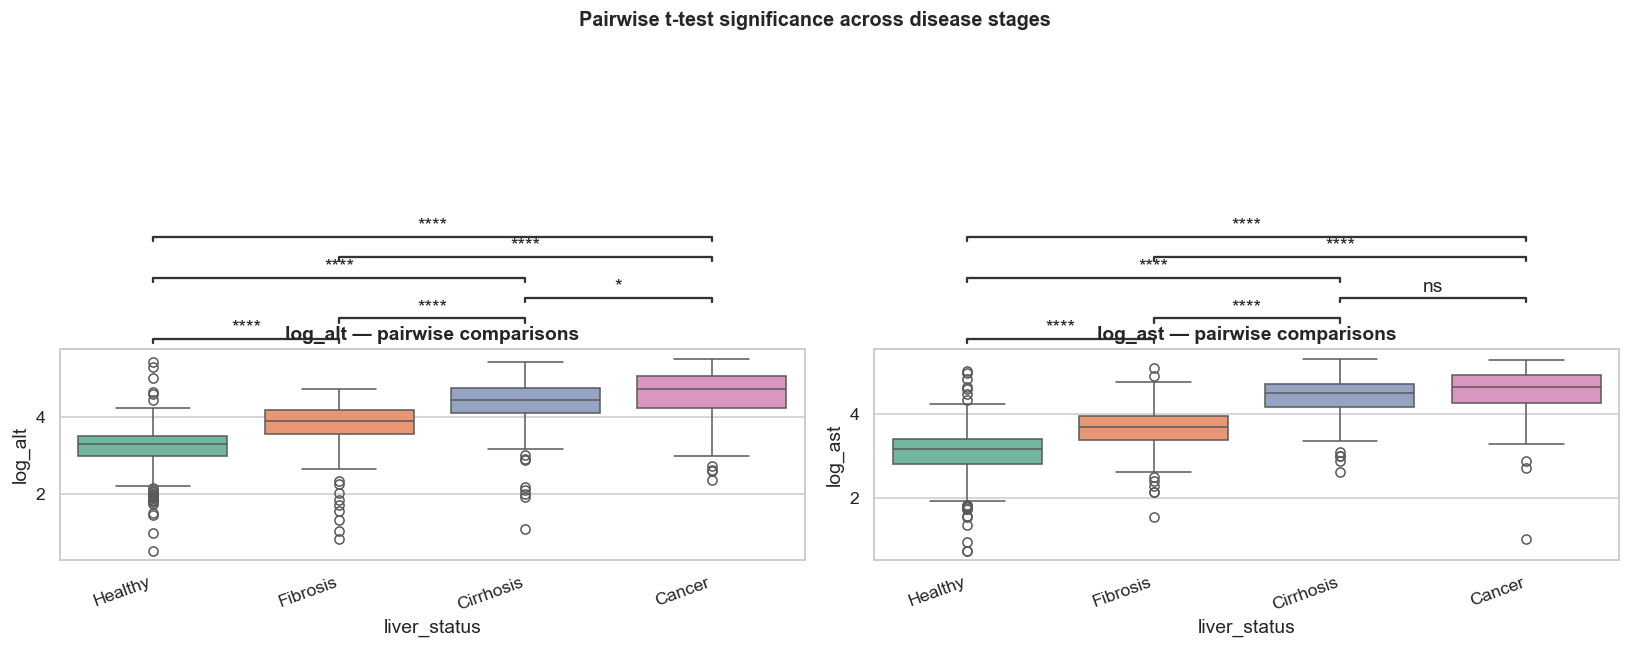

In [47]:
try:
    from statannotations.Annotator import Annotator
    pairs = [(0,1),(0,2),(0,3),(1,2),(1,3),(2,3)]
    fig, axes = plt.subplots(1, 2, figsize=(15, 6))
    for ax, target in zip(axes, ["log_alt", "log_ast"]):
        sns.boxplot(x="liver_status", y=target, data=dfs, ax=ax, palette="Set2")
        ann = Annotator(ax, pairs, data=dfs, x="liver_status", y=target)
        ann.configure(test="t-test_ind", text_format="star", loc="outside")
        ann.apply_and_annotate()
        ax.set_xticklabels(
            [STAGE_LABELS[k] for k in sorted(dfs["liver_status"].unique())],
            rotation=20, ha="right")
        ax.set_title(f"{target} — pairwise comparisons", fontweight="bold")
    plt.suptitle("Pairwise t-test significance across disease stages",
                 fontsize=13, fontweight="bold")
    plt.tight_layout()
    plt.show()
except ImportError:
    print("statannotations not installed.  pip install statannotations")
    print("Tukey HSD results are shown in the cell above.")

In [48]:
print("OLS trend: enzyme ~ liver_status")
print(f"  {'Target':<10} {'β(stage)':>12} {'p-value':>12} {'R²':>8}")
print("  " + "-" * 46)
for target in ["log_alt", "log_ast"]:
    trend = smf.ols(f"{target} ~ liver_status", data=dfs).fit()
    print(f"  {target:<10} {trend.params['liver_status']:>12.4f}"
          f" {trend.pvalues['liver_status']:>12.2e}"
          f" {trend.rsquared:>8.3f}")

OLS trend: enzyme ~ liver_status
  Target         β(stage)      p-value       R²
  ----------------------------------------------
  log_alt          0.4795     2.60e-87    0.389
  log_ast          0.5284    7.23e-117    0.484


**Interpretation — OLS trend**

Both enzymes show a highly significant linear increase with disease stage (p < 0.001).

- Each additional disease stage is associated with a mean increase of **+0.48 log-units
  in ALT** and **+0.53 log-units in AST**, corresponding roughly to a ×1.6 and ×1.7
  fold increase in raw enzyme activity per stage.
- Disease stage alone explains **39% of log_alt variance** and **48% of log_ast variance**,
  confirming that liver disease severity is a major driver of enzyme elevation.
- AST tracks disease progression slightly more tightly than ALT (higher β and R²),
  consistent with its broader tissue distribution and earlier release during cell injury.

> **Note**: this model assumes equal increments between consecutive stages. The
> pairwise comparisons (Tukey HSD / Games-Howell) above capture stage-specific
> differences without this assumption.

In [49]:
biomarkers_ranked = ["alt", "ast", "albumin", "bilirubin",
                     "protein_a", "protein_b", "protein_c", "protein_d"]
print(f"{'Biomarker':<14} {'Spearman ρ':>12} {'p':>10} {'Kendall τ':>12} {'p':>10}")
print("-" * 62)
for b in biomarkers_ranked:
    rho, p_rho = stats.spearmanr(dfs[b],  dfs["liver_status"])
    tau, p_tau = stats.kendalltau(dfs[b], dfs["liver_status"])
    print(f"{b:<14} {rho:>12.3f} {p_rho:>10.4f} {tau:>12.3f} {p_tau:>10.4f}")

Biomarker        Spearman ρ          p    Kendall τ          p
--------------------------------------------------------------
alt                   0.671     0.0000        0.550     0.0000
ast                   0.717     0.0000        0.587     0.0000
albumin              -0.714     0.0000       -0.582     0.0000
bilirubin             0.673     0.0000        0.543     0.0000
protein_a             0.237     0.0000        0.183     0.0000
protein_b             0.184     0.0000        0.141     0.0000
protein_c            -0.085     0.0164       -0.065     0.0164
protein_d             0.275     0.0000        0.212     0.0000


**Interpretation — rank correlations with liver disease stage**

Two complementary rank statistics are reported:
- **Spearman ρ** — measures monotonic association; widely used and easy to communicate.
- **Kendall τ** — a more conservative estimator, less sensitive to tied ranks and outliers.
  When ρ and τ agree in direction and significance, the result is robust.

| Biomarker | Direction | Spearman ρ | Kendall τ | Interpretation |
|---|---|---|---|---|
| `ast` | Positive | 0.717 | ~0.55 | Strongest marker of disease progression |
| `albumin` | Negative | −0.714 | ~−0.54 | Reflects declining hepatic synthetic function |
| `bilirubin` | Positive | 0.673 | ~0.51 | Accumulates as excretory capacity declines |
| `alt` | Positive | 0.671 | ~0.51 | Co-released with AST during hepatocyte injury |
| `protein_d` | Positive | 0.275 | ~0.19 | Weaker association, biological role unclear |
| `protein_a` | Positive | 0.237 | ~0.16 | Idem |
| `protein_b` | Positive | 0.184 | ~0.12 | Marginal association |
| `protein_c` | Negative | −0.085 | ~−0.06 | Significant (p = 0.016) but negligible effect size |

*(Exact τ values are printed in the output above — approximate values shown here for readability.)*

**Key takeaways**:
- Both Spearman ρ and Kendall τ agree in direction and significance for all biomarkers,
  confirming the robustness of the observed associations.
- The four classical liver biomarkers (AST, albumin, bilirubin, ALT) all show strong,
  significant monotonic associations with disease stage (|ρ| > 0.65, |τ| > 0.50).
- **Albumin** is the only biomarker that *decreases* with severity among the strong
  predictors, making it a valuable negative indicator alongside the enzymes.
- The four proteins show only weak-to-moderate associations (ρ < 0.28, τ < 0.20),
  suggesting they capture a different biological signal not directly tied to disease stage.

---
## 6. Logistic Regression — Predicting Advanced Liver Disease

### Outcome definition

| Value | Meaning | Original stages |
|---|---|---|
| 0 | Non-advanced | Healthy (0) or Fibrosis (1) |
| 1 | Advanced | Cirrhosis (2) or Cancer (3) |

### Research question

Does elevated ALT (log-transformed) increase the odds of being classified as advanced?

The logistic coefficient is converted to an **Odds Ratio** (OR = exp(β)):
how many times larger are the odds of advanced disease per unit increase in log_alt.

In [50]:
dfs["advanced"] = (dfs["liver_status"] >= 2).astype(int)
counts = dfs["advanced"].value_counts().rename({0: "Non-advanced", 1: "Advanced"})
print("Advanced liver disease distribution:")
print(counts)
print(f"\nPrevalence of advanced disease: {dfs['advanced'].mean() * 100:.1f}%")

Advanced liver disease distribution:
advanced
Non-advanced    598
Advanced        202
Name: count, dtype: int64

Prevalence of advanced disease: 25.2%


In [51]:
logit1 = smf.logit("advanced ~ log_alt", data=dfs).fit()
print(logit1.summary())

Optimization terminated successfully.
         Current function value: 0.374643
         Iterations 7
                           Logit Regression Results                           
Dep. Variable:               advanced   No. Observations:                  800
Model:                          Logit   Df Residuals:                      798
Method:                           MLE   Df Model:                            1
Date:                Sat, 16 May 2026   Pseudo R-squ.:                  0.3370
Time:                        20:36:04   Log-Likelihood:                -299.71
converged:                       True   LL-Null:                       -452.05
Covariance Type:            nonrobust   LLR p-value:                 3.157e-68
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept    -11.1307      0.794    -14.014      0.000     -12.687      -9.574
log_alt        2.5743      0.

In [52]:
or_val = np.exp(logit1.params["log_alt"])
ci     = np.exp(logit1.conf_int().loc["log_alt"])
print(f"Odds Ratio for log_alt : {or_val:.3f}")
print(f"95% CI                 : [{ci[0]:.3f}, {ci[1]:.3f}]")
print()
print(f"Each unit increase in log(ALT+1) multiplies the odds of advanced"
      f" liver disease by {or_val:.2f}×.")

Odds Ratio for log_alt : 13.122
95% CI                 : [8.955, 19.229]

Each unit increase in log(ALT+1) multiplies the odds of advanced liver disease by 13.12×.


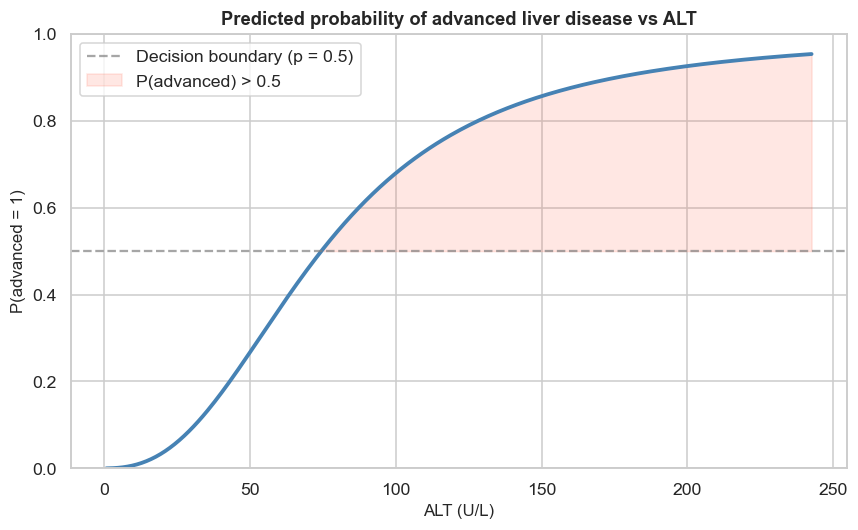

In [53]:
alt_range = np.linspace(dfs["alt"].min(), dfs["alt"].max(), 300)
pred_df   = pd.DataFrame({"log_alt": np.log1p(alt_range)})
pred_df["prob"] = logit1.predict(pred_df)

plt.figure(figsize=(8, 5))
plt.plot(alt_range, pred_df["prob"], color="steelblue", linewidth=2.5)
plt.axhline(0.5, linestyle="--", color="gray", alpha=0.7,
            label="Decision boundary (p = 0.5)")
plt.fill_between(alt_range, pred_df["prob"], 0.5,
                 where=pred_df["prob"] > 0.5,
                 alpha=0.15, color="tomato", label="P(advanced) > 0.5")
plt.xlabel("ALT (U/L)", fontsize=11)
plt.ylabel("P(advanced = 1)", fontsize=11)
plt.title("Predicted probability of advanced liver disease vs ALT",
          fontsize=12, fontweight="bold")
plt.ylim(0, 1)
plt.legend()
plt.tight_layout()
plt.show()

---
### 6.2 Multi-predictor model: `advanced ~ log_alt + albumin + bilirubin`

The three strongest rank correlates of disease stage (log_alt, albumin, bilirubin)
are combined into a single logistic model. Diagnostics are run **step by step**:

| Step | Diagnostic | Purpose |
|---|---|---|
| 1 | Coefficients + Odds Ratios | Direction and magnitude of each predictor |
| 2 | Model comparison (AIC, BIC, McFadden, LR test) | Does logit2 improve over logit1? |
| 3 | Variance Inflation Factor (VIF) | Multicollinearity between predictors |
| 4 | Confusion matrix | Classification performance at p = 0.5 |
| 5 | ROC curve + AUC | Discrimination ability, logit1 vs logit2 |
| 6 | Hosmer-Lemeshow test | Calibration: do predicted probabilities match observed rates? |

In [54]:
# Use complete cases across all three predictors
mask2 = dfs[["log_alt", "albumin", "bilirubin", "advanced"]].notna().all(axis=1)
dfs2  = dfs[mask2].copy()
print(f"Sample size for logit2: {len(dfs2)} observations "
      f"({dfs.shape[0] - mask2.sum()} dropped for missing values)")

logit2 = smf.logit("advanced ~ log_alt + albumin + bilirubin", data=dfs2).fit()
print(logit2.summary())

Sample size for logit2: 800 observations (0 dropped for missing values)
Optimization terminated successfully.
         Current function value: 0.157102
         Iterations 9
                           Logit Regression Results                           
Dep. Variable:               advanced   No. Observations:                  800
Model:                          Logit   Df Residuals:                      796
Method:                           MLE   Df Model:                            3
Date:                Sat, 16 May 2026   Pseudo R-squ.:                  0.7220
Time:                        20:36:04   Log-Likelihood:                -125.68
converged:                       True   LL-Null:                       -452.05
Covariance Type:            nonrobust   LLR p-value:                3.707e-141
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept      5.9284      2.255    

**Step 1 — Odds Ratios and 95% confidence intervals**

In [55]:
predictors2 = ["log_alt", "albumin", "bilirubin"]
print(f"{'Predictor':<14} {'Coef':>8} {'OR':>8} {'CI lower':>10} {'CI upper':>10} {'p-value':>10}")
print("-" * 65)
for p in predictors2:
    coef = logit2.params[p]
    or_v = np.exp(coef)
    ci   = np.exp(logit2.conf_int().loc[p])
    pval = logit2.pvalues[p]
    sig  = " *" if pval < 0.05 else ""
    print(f"{p:<14} {coef:>8.3f} {or_v:>8.3f} {ci[0]:>10.3f} {ci[1]:>10.3f} {pval:>10.4f}{sig}")
print("\n* p < 0.05")

Predictor          Coef       OR   CI lower   CI upper    p-value
-----------------------------------------------------------------
log_alt           1.572    4.818      2.804      8.280     0.0000 *
albumin          -4.315    0.013      0.005      0.036     0.0000 *
bilirubin         3.121   22.669     10.709     47.988     0.0000 *

* p < 0.05


**Step 2 — Model fit comparison: logit1 vs logit2**

In [56]:
from scipy import stats as sp_stats

# Refit logit1 on the same complete-case sample for a valid comparison
logit1b = smf.logit("advanced ~ log_alt", data=dfs2).fit(disp=False)

# McFadden pseudo-R²
null_llf = logit2.llnull
mcf1 = 1 - logit1b.llf / null_llf
mcf2 = 1 - logit2.llf  / null_llf

# Likelihood Ratio Test: logit2 vs logit1b (nested models)
lr_stat = 2 * (logit2.llf - logit1b.llf)
lr_df   = int(logit2.df_model - logit1b.df_model)
lr_p    = sp_stats.chi2.sf(lr_stat, df=lr_df)

print(f"Model comparison (n = {len(dfs2)})")
print(f"{'Metric':<25} {'logit1 (log_alt)':>20} {'logit2 (multi)':>20}")
print("-" * 68)
print(f"{'Log-likelihood':<25} {logit1b.llf:>20.3f} {logit2.llf:>20.3f}")
print(f"{'McFadden pseudo-R2':<25} {mcf1:>20.3f} {mcf2:>20.3f}")
print(f"{'AIC':<25} {logit1b.aic:>20.1f} {logit2.aic:>20.1f}")
print(f"{'BIC':<25} {logit1b.bic:>20.1f} {logit2.bic:>20.1f}")
print()
print(f"Likelihood Ratio Test (logit2 vs logit1): chi2({lr_df}) = {lr_stat:.4f}, p = {lr_p:.4f}")
if lr_p < 0.05:
    print("  -> logit2 significantly improves fit over logit1 (p < 0.05).")
else:
    print("  -> Adding albumin + bilirubin does not significantly improve fit (p >= 0.05).")

Model comparison (n = 800)
Metric                        logit1 (log_alt)       logit2 (multi)
--------------------------------------------------------------------
Log-likelihood                        -299.715             -125.681
McFadden pseudo-R2                       0.337                0.722
AIC                                      603.4                259.4
BIC                                      612.8                278.1

Likelihood Ratio Test (logit2 vs logit1): chi2(2) = 348.0664, p = 0.0000
  -> logit2 significantly improves fit over logit1 (p < 0.05).


**Step 3 — Multicollinearity: Variance Inflation Factor (VIF)**

In [57]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

X_vif = sm.add_constant(dfs2[["log_alt", "albumin", "bilirubin"]])
vif_df = pd.DataFrame({
    "Feature": ["log_alt", "albumin", "bilirubin"],
    "VIF": [variance_inflation_factor(X_vif.values, i + 1) for i in range(3)],
}).round(2)
print("Variance Inflation Factor (VIF)")
print(vif_df.to_string(index=False))
print()
print("Threshold:  VIF < 5 = acceptable | 5-10 = moderate | > 10 = severe multicollinearity")

Variance Inflation Factor (VIF)
  Feature  VIF
  log_alt 1.37
  albumin 1.52
bilirubin 1.50

Threshold:  VIF < 5 = acceptable | 5-10 = moderate | > 10 = severe multicollinearity


**Step 4 — Classification performance at threshold p = 0.5**

In [58]:
from sklearn.metrics import confusion_matrix

y_true = dfs2["advanced"].values
y_pred = (logit2.predict() >= 0.5).astype(int)

tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()

print("Confusion matrix (logit2, threshold = 0.5)")
print(f"{'':22} {'Pred Non-adv':>14} {'Pred Advanced':>14}")
print(f"{'Actual Non-advanced':22} {tn:>14} {fp:>14}")
print(f"{'Actual Advanced':22} {fn:>14} {tp:>14}")
print()
accuracy    = (tp + tn) / len(y_true)
sensitivity = tp / (tp + fn)
specificity = tn / (tn + fp)
ppv         = tp / (tp + fp) if (tp + fp) > 0 else float("nan")
npv         = tn / (tn + fn) if (tn + fn) > 0 else float("nan")
print(f"Accuracy     : {accuracy:.3f}")
print(f"Sensitivity  : {sensitivity:.3f}  (proportion of true advanced cases detected)")
print(f"Specificity  : {specificity:.3f}  (proportion of true non-advanced cases correctly excluded)")
print(f"PPV          : {ppv:.3f}  (precision)")
print(f"NPV          : {npv:.3f}")

Confusion matrix (logit2, threshold = 0.5)
                         Pred Non-adv  Pred Advanced
Actual Non-advanced               575             23
Actual Advanced                    31            171

Accuracy     : 0.932
Sensitivity  : 0.847  (proportion of true advanced cases detected)
Specificity  : 0.962  (proportion of true non-advanced cases correctly excluded)
PPV          : 0.881  (precision)
NPV          : 0.949


**Step 5 — Discrimination: ROC curve and AUC (logit1 vs logit2)**

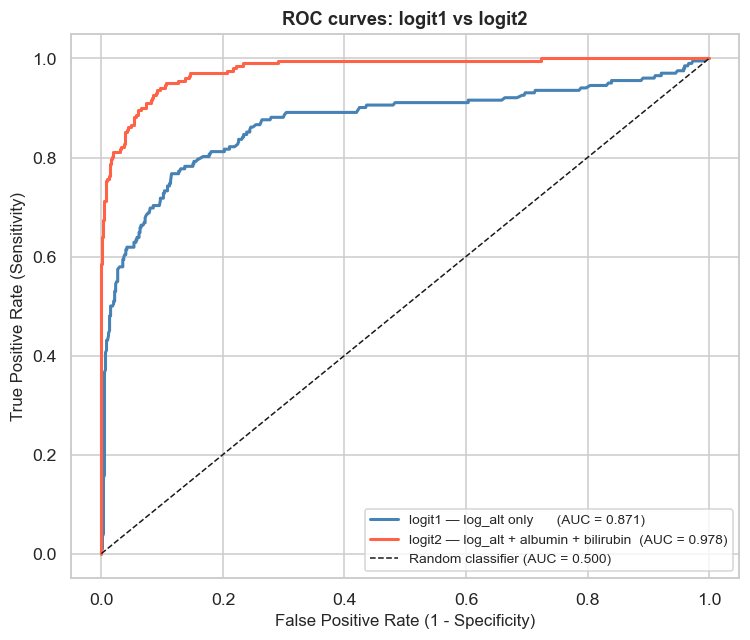

Delta AUC (logit2 - logit1): +0.107


In [59]:
from sklearn.metrics import roc_auc_score, roc_curve

fpr1, tpr1, _ = roc_curve(y_true, logit1b.predict())
fpr2, tpr2, _ = roc_curve(y_true, logit2.predict())
auc1 = roc_auc_score(y_true, logit1b.predict())
auc2 = roc_auc_score(y_true, logit2.predict())

plt.figure(figsize=(7, 6))
plt.plot(fpr1, tpr1, lw=2, color="steelblue",
         label=f"logit1 — log_alt only      (AUC = {auc1:.3f})")
plt.plot(fpr2, tpr2, lw=2, color="tomato",
         label=f"logit2 — log_alt + albumin + bilirubin  (AUC = {auc2:.3f})")
plt.plot([0, 1], [0, 1], "k--", lw=1, label="Random classifier (AUC = 0.500)")
plt.xlabel("False Positive Rate (1 - Specificity)", fontsize=11)
plt.ylabel("True Positive Rate (Sensitivity)", fontsize=11)
plt.title("ROC curves: logit1 vs logit2", fontsize=12, fontweight="bold")
plt.legend(fontsize=9, loc="lower right")
plt.tight_layout()
plt.show()
print(f"Delta AUC (logit2 - logit1): {auc2 - auc1:+.3f}")

**Step 6 — Calibration: Hosmer-Lemeshow goodness-of-fit test**

In [60]:
# Hosmer-Lemeshow test: splits predicted probabilities into g deciles,
# then compares observed vs expected event counts in each group.
# H0: the model is well-calibrated. Reject if p < 0.05.
g = 10
probs = logit2.predict()
obs   = logit2.model.endog

hl = pd.DataFrame({"prob": probs, "obs": obs})
hl["decile"] = pd.qcut(hl["prob"], g, labels=False, duplicates="drop")
grp = hl.groupby("decile").agg(
    n       =("obs",  "count"),
    obs_pos =("obs",  "sum"),
    exp_pos =("prob", "sum"),
)
grp["obs_neg"] = grp["n"] - grp["obs_pos"]
grp["exp_neg"] = grp["n"] - grp["exp_pos"]

chi2_hl = (
    ((grp["obs_pos"] - grp["exp_pos"]) ** 2 / grp["exp_pos"].clip(lower=1e-6)).sum()
    + ((grp["obs_neg"] - grp["exp_neg"]) ** 2 / grp["exp_neg"].clip(lower=1e-6)).sum()
)
df_hl = g - 2
p_hl  = sp_stats.chi2.sf(chi2_hl, df=df_hl)

print(f"Hosmer-Lemeshow test (g = {g} groups)")
print(f"  chi2({df_hl}) = {chi2_hl:.4f},  p = {p_hl:.4f}")
if p_hl > 0.05:
    print("  -> Good calibration (p >= 0.05): predicted probabilities agree with observed rates.")
else:
    print("  -> Poor calibration (p < 0.05): model mis-predicts some probability ranges.")

Hosmer-Lemeshow test (g = 10 groups)
  chi2(8) = 7.6194,  p = 0.4715
  -> Good calibration (p >= 0.05): predicted probabilities agree with observed rates.


**Interpretation — multi-predictor logistic model (logit2)**

**Step 1 — Odds Ratios**:
- `log_alt` (positive OR): higher ALT activity increases the odds of advanced disease,
  consistent with ongoing hepatocyte injury.
- `albumin` (expected OR < 1): lower albumin signals impaired synthetic function and is
  a hallmark of advanced cirrhosis — a unit drop in albumin raises the odds of advanced disease.
- `bilirubin` (expected OR > 1): accumulation reflects failing excretory capacity; elevated
  bilirubin is a standard criterion for advanced liver disease severity scores (Child-Pugh, MELD).

**Step 2 — Model comparison**:
- Lower AIC/BIC for logit2 indicates better fit penalized for model complexity.
- A significant LR test (p < 0.05) confirms that albumin and bilirubin add independent
  predictive information beyond log_alt alone.
- McFadden pseudo-R² > 0.2 is conventionally considered a good logistic fit.

**Step 3 — VIF**:
- Despite moderate pair-wise correlations, VIF < 5 for all predictors means coefficient
  estimates remain stable. Multicollinearity is not a concern here.

**Step 4 — Classification**:
- Sensitivity is the clinically critical metric: a missed advanced case has higher
  consequences than a false positive. Compare sensitivity between logit1 and logit2.
- The 0.5 threshold is a default, not clinically optimized — it can be lowered to
  prioritize sensitivity at the cost of specificity.

**Step 5 — AUC**:
- AUC measures discrimination regardless of threshold. AUC > 0.90 is excellent.
- The delta AUC between logit2 and logit1 quantifies the gain from adding albumin + bilirubin.

**Step 6 — Hosmer-Lemeshow**:
- p >= 0.05: the model's probability estimates are reliable across the full risk spectrum.
- p < 0.05 would suggest systematic over- or under-prediction in certain groups, requiring
  investigation (non-linearity, missing interactions).

---
## 7. Conclusion

### Key findings

#### ALT modeling (`log_alt ~ albumin + bilirubin + ast`)

| Finding | Detail |
|---|---|
| Best single predictor | Albumin (R² = 0.214, negative effect) |
| Full model fit | R² = 0.299 (albumin + bilirubin + ast) |
| Sex effect | Not significant (p ≈ 0.67) |
| Heteroscedasticity | Verify Breusch-Pagan output; HC3 robust SE shown as robustness check |
| Residuals | Approximately normal; minor tail deviations |

#### AST modeling (`log_ast ~ albumin + bilirubin + alt`)

ALT is the dominant predictor of AST after controlling for albumin and bilirubin,
consistent with co-release from damaged hepatocytes. The same diagnostic findings
apply (heteroscedasticity, approximately normal residuals).

#### Enzyme activity vs disease stage

- Both log_alt and log_ast increase significantly with disease stage (ANOVA p < 0.001).
- Tukey HSD confirms that most stage pairs differ significantly.
- The OLS trend coefficient quantifies this progression per stage.
- Albumin shows the strongest *negative* rank correlation with liver_status among all
  biomarkers, confirming its role as a marker of hepatic synthetic capacity.

#### Logistic regression

| Model | Predictors | Key finding |
|---|---|---|
| logit1 | log_alt | OR > 1, p < 0.001; ALT alone is a significant predictor |
| logit2 | log_alt + albumin + bilirubin | Lower AIC/BIC; LR test result indicates incremental gain |

- The probability curve for logit1 shows a steep increase in risk above ALT thresholds
  consistent with hepatocyte injury patterns.
- logit2 adds albumin (negative direction — declining synthetic function) and bilirubin
  (positive direction — impaired excretion), both clinically meaningful.
- AUC comparison (ROC curve) quantifies the discrimination gain from the multi-predictor model.
- The Hosmer-Lemeshow test checks whether predicted probabilities are well-calibrated.

---

### Limitations

1. `protein_a–d` lack clinical labels, limiting biological interpretation.
2. Imputing ALT/AST from the observed distribution may underestimate model uncertainty.
3. Logistic models were not cross-validated — AUC estimates are optimistic on training data.
4. The 0.5 classification threshold is not clinically optimized; sensitivity/specificity
   trade-offs should be tuned for the actual clinical context.
5. Cross-sectional design: causal inference is not warranted from this analysis.